<a href="https://colab.research.google.com/github/thuc-github/MIS710-T12023/blob/main/A1/MIS710%20A1%20Template%20T1%202023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIS710 Machine Learning in Business - Assignment 1

**Student Name:** Danny Chen

**Student ID:** s226000331

# **Assignment Template**


The template here guides you to complete the assignment. Refer to the rubric for more details.

- Code, outputs, and brief comments are subject to assessment.
- Full result details must be presented in the Report, not here. The Report is subject to assessment.


## **1. Business Understanding**

**Aim:** To clearly articulate your understanding of the business problem to management.

Use this section to briefly include:
- **Context:** Internal and external business environment: industry, and organisational background relevant to the case study; relate to broader readings and theoretical frameworks
- **Needs:** The business problem to address and stakeholder needs; connect to specific details and evidence from the case study
- **Solution:** How machine learning will address the business problem and achieve business objectives; justify with reference to case study context
- **Value Proposition:** The expected benefits, outcomes, and value that the machine learning solution will deliver; support with evidence from the case study and relevant literature
- **Stakeholders:** Key stakeholders, their interests, and how they will be affected by the solution; identify specific stakeholders mentioned or implied in the case study
- **Change:** Recommendations for implementation, organisational changes required, and how success will be measured; ground recommendations in case study details and broader readings

**Business need:**

There is currently a lack of an accurate and reliable method to estimate CO₂ emissions for individual vehicles.


*   If emissions are underestimated, actual CO₂ levels in the atmosphere will exceed targets, undermining environmental goals.
*   If emissions are overestimated for certain brands, it may unfairly trigger negative consumer perception and reduce sales in the automotive industry.
A precise prediction model is therefore essential to support both environmental regulation and fair market practices.



**Solution:**

Utilise a historical vehicle dataset containing features such as engine size, number of cylinders, and fuel consumption to build a machine learning regression model that predicts CO₂ emissions for each vehicle. By selecting the most relevant features and optimising model performance, the solution aims to deliver accurate and reliable emission estimates.


**Value:**


*   Increase transparency around CO₂ emissions across vehicle brands and models
*   Raise environmental awareness among consumers and industry stakeholders
*   Enable easier and more cost-effective monitoring of CO₂ production
*   Support government bodies and manufacturers in making better-informed environmental policy decisions
*   Help consumers make more environmentally conscious purchasing choices


**Change:**

The introduction of a machine learning–based prediction model transforms the CO2 estimation process from traditional, costly, and time-consuming measurement methods to a data-driven, automated approach. Specifically, this change involves:


*   Speed and accuracy: Predictions can be generated almost instantly once the model is trained, replacing slow laboratory-based testing with rapid, data-driven estimates that maintain a high level of accuracy.
*   Simplicity of inputs: Using only a small set of readily available vehicle specifications (such as engine size, number of cylinders, and fuel consumption), the model can predict CO2 emissions without requiring expensive physical testing equipment.


*   Scalability: The model can be applied across thousands of vehicles simultaneously, making it feasible to estimate emissions for entire product lines or national fleets rather than testing one car at a time.
*   Decision-making process: Stakeholders shift from relying on limited, manually collected emission data to having access to comprehensive, model-generated insights that support faster and more informed policy and business decisions.




**Context:**


*   Climate change is a growing global concern, with governments worldwide introducing stricter carbon emission regulations (e.g., EU emission standards)
*   The automotive industry is undergoing a significant transition, with the rise of electric vehicles and increasing consumer demand for environmentally friendly options
*   Existing CO₂ measurement methods can be expensive and slow; a machine learning model offers a faster and more scalable alternative
*   The dataset used has its own limitations, including the time range of the data, the brands and vehicle types covered, and the geographic scope
*   The project leverages current data science tools, technologies and skilled employee to develop and monitoring the result to get the best output.












**Stakeholder:**



*   Government environmental regulatory bodies
*   Automobile manufacturers
*   Consumers
*   Environmental advocacy organisations
*   The analytics team for building and maintaining the model







## **2. Data Understanding, Preparation, Exploration and Visualisation**

**Aim:** Demonstrate clear understanding of the data and generate insights relevant to the business problem.

**Data Preparation and Exploration**
- Clean and prepare the dataset for analysis  
- Handle missing or unrealistic values  
- Apply necessary transformations (e.g., encoding, scaling, type conversion)  
- Select and justify relevant features  
- Select and justify the label (target)  

**Analysis and Visualisation**
- Conduct univariate, bivariate, and multivariate analyses  
- Identify patterns relevant to the case study and client questions  
- Present clear visualisations of key variables  

All visualisations must include concise discussion of insights and implications.

**Data Insights, Business Interpretation, and Recommendation**s

For each key finding:

- State the data insight  
- Interpret its business meaning  
- Provide client recommendations  
- Explain implications for ML model development  

## **Import Libraries**

In [379]:
# Load required libraries

# Load data from Colab

import pandas as pd #for data manipulation and analysis
import numpy as np #for working with arrays

#Import data visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

#import linear_model
from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Import train_test_split function
from sklearn.model_selection import train_test_split



# post analysis
import statsmodels.api as sm






## **Mount My Google drive**

In [380]:
# Code
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Data loading**


1.   Load the dataset
2.   Explore the data

In [381]:
# load dataset stored in my Google drive
records = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/A1/AESC_ CO2e_data.csv")

print(records)

print('Sample size:', records.shape[0])

# total sample for later use
total_sample_size = records.shape[0]
print('Number of columns:', records.shape[1])

# Save a copy of the original dataset before any treatment
records_original = records.copy()


     Dealer_ID Dealer_State       Make         Vehicle Category  \
0         D003           WA    PORSCHE                FULL-SIZE   
1         D027          VIC        BMW               SUBCOMPACT   
2         D016          NSW        GMC  PICKUP TRUCK - STANDARD   
3         D025           WA  CHEVROLET  PICKUP TRUCK - STANDARD   
4         D020          QLD     TOYOTA           SUV - STANDARD   
...        ...          ...        ...                      ...   
6680      D056           WA      BUICK              SUV - SMALL   
6681      D049          QLD     TOYOTA                 MID-SIZE   
6682      D025           WA   CHRYSLER                 MID-SIZE   
6683      D032          TAS     JAGUAR               TWO-SEATER   
6684      D052          NSW     JAGUAR               TWO-SEATER   

     Vehicle Colour Listing Month Transmission Type Fuel Type  Cylinders  \
0            Orange           Oct               AM8         Z          6   
1             Brown           Jul          

In [382]:
#Inspecting how the data is stored (data types)

print(records.info())
print('\nData Rows and Columns ',records.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6685 entries, 0 to 6684
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dealer_ID          6685 non-null   object 
 1   Dealer_State       6685 non-null   object 
 2   Make               6685 non-null   object 
 3   Vehicle Category   6685 non-null   object 
 4   Vehicle Colour     6485 non-null   object 
 5   Listing Month      6685 non-null   object 
 6   Transmission Type  6418 non-null   object 
 7   Fuel Type          6685 non-null   object 
 8   Cylinders          6518 non-null   float64
 9   Engine Size        6485 non-null   float64
 10  CO2 Emissions      6685 non-null   float64
dtypes: float64(3), object(8)
memory usage: 574.6+ KB
None

Data Rows and Columns  (6685, 11)


Result shows dataset has **6685 rows**, **11 columns**


In [383]:
#Displaing the first 5 rows of data
records.head()


,Dealer_ID,Dealer_State,Make,Vehicle Category,Vehicle Colour,Listing Month,Transmission Type,Fuel Type,Cylinders,Engine Size,CO2 Emissions
0,D003,WA,PORSCHE,FULL-SIZE,Orange,Oct,AM8,Z,6,3,253
1,D027,VIC,BMW,SUBCOMPACT,Brown,Jul,AM7,Z,8,4,344
2,D016,NSW,GMC,PICKUP TRUCK - STANDARD,Red,Jun,A8,Z,8,6,322
3,D025,WA,CHEVROLET,PICKUP TRUCK - STANDARD,Red,Jul,A6,X,8,NaN,297
4,D020,QLD,TOYOTA,SUV - STANDARD,Black,Nov,AS5,X,6,4,308


**First quick peek from the dataset first 5 rows**


*   **Null value  in Engine Size** appeared  in **Dealer_ID D025**. (Data will require treatment)
*   We will need to find article in the industry to identify **Fuel type** meaning Z,X etc...




In [384]:
#Displaying the last 5 rows of data
records.tail()


,Dealer_ID,Dealer_State,Make,Vehicle Category,Vehicle Colour,Listing Month,Transmission Type,Fuel Type,Cylinders,Engine Size,CO2 Emissions
6680,D056,WA,BUICK,SUV - SMALL,Black,Aug,AS6,X,6,1,212
6681,D049,QLD,TOYOTA,MID-SIZE,Black,Mar,AS8,X,6,4,220
6682,D025,WA,CHRYSLER,MID-SIZE,White,Apr,A9,E,6,4,230
6683,D032,TAS,JAGUAR,TWO-SEATER,White,Aug,AS8,Z,8,5,311
6684,D052,NSW,JAGUAR,TWO-SEATER,White,Aug,M6,Z,6,3,302


In [385]:
records.sample(10)
#Random sampling 10 data from the dataset

,Dealer_ID,Dealer_State,Make,Vehicle Category,Vehicle Colour,Listing Month,Transmission Type,Fuel Type,Cylinders,Engine Size,CO2 Emissions
2863,D019,WA,CHEVROLET,SUBCOMPACT,Black,Dec,AS8,Z,4,6,220
2476,D037,NSW,MERCEDES-BENZ,TWO-SEATER,Grey,Nov,AS7,Z,6,NaN,225
6444,D018,NSW,RAM,PICKUP TRUCK - STANDARD,White,Apr,A8,X,6,4,245
2580,D040,QLD,VOLVO,COMPACT,White,Feb,AS8,X,4,2,193
6531,D043,QLD,RAM,PICKUP TRUCK - STANDARD,White,Mar,A8,X,6,4,260
2988,D019,WA,BMW,FULL-SIZE,Silver,Mar,AS8,Z,8,4,283
4957,D031,QLD,JAGUAR,COMPACT,Red,Dec,AS8,D,4,2,186
4781,D053,WA,AUDI,SUBCOMPACT,Silver,Aug,AS8,Z,6,3,234
471,D019,WA,MERCEDES-BENZ,FULL-SIZE,Blue,Sep,AS7,Z,8,6,313
749,D040,QLD,CHRYSLER,FULL-SIZE,White,Oct,A8,X,6,4,257


Null value in veichle color appeared in **Dealer_ID D008** and **D019**.

Dealer_State in **Dealer_ID D056** shows Unknown.
We will count how many Unknown value for **Dealer_State** then decide on how are we proceed from there

We can drop this column as the industry paper suggest less correlation between **Vehicle Colour** and **CO2 Emissions**

## **Data formatting**

In [386]:
# display output to 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)


## **2.1 Missing Data Inspection**


In [387]:
# Print the sum of null values in each column
print(records.isnull().sum())


Dealer_ID              0
Dealer_State           0
Make                   0
Vehicle Category       0
Vehicle Colour       200
Listing Month          0
Transmission Type    267
Fuel Type              0
Cylinders            167
Engine Size          200
CO2 Emissions          0
dtype: int64


Result shows missing values for each column are:

Vehicle Colour: **200**

Transmission Type: **267**

Cylinders: **167**

Engine Size: **200**

## **⬇️ Initial EDA for Numercial Data**

###**Univariate analysis**

### **Addressing Business Needs**
### **Summarise CO2 Emissions**

count   6685.00
mean     250.73
std       58.71
min       96.00
25%      208.00
50%      246.00
75%      289.00
max      601.50
Name: CO2 Emissions, dtype: float64


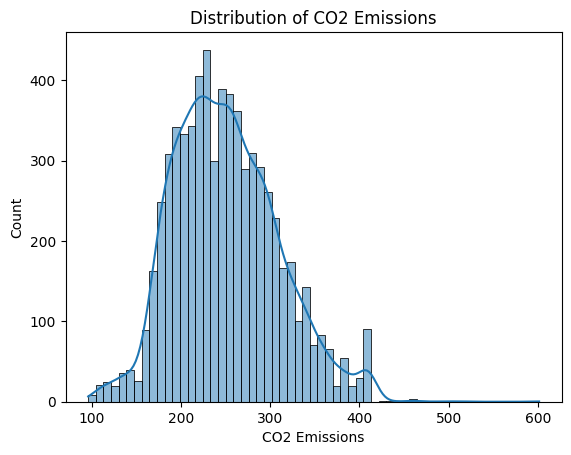

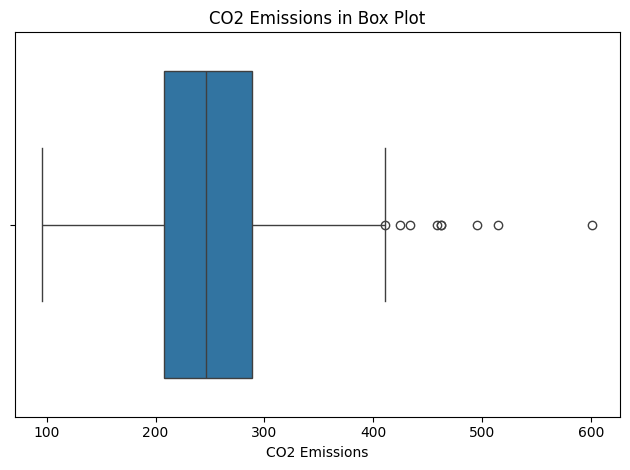

In [388]:
# CO2 missions per kilometre. (g/km)
# CO2 Statstic Summary
print(records['CO2 Emissions'].describe())

# Visualising CO2 Emissions in histogram
sns.histplot(data=records, x='CO2 Emissions', kde=True)
plt.title('Distribution of CO2 Emissions')
plt.show()

# Visualising CO2 Emissions in Box Plot to see outliners
sns.boxplot(data=records, x='CO2 Emissions',)
plt.title('CO2 Emissions in Box Plot')
plt.tight_layout()
plt.show()




**Data Insights:**

CO2 emissions range from 96 to 601.5 g/km, with a mean of 250.7 g/km and a median of 246 g/km. The distribution is slightly right-skewed, as shown in the charts above.

**Business Interpretation:**

1.   The majority of vehicles on the market produce CO2 emissions between 200 and 285 g/km, representing the mainstream emission level in the current market.
2.   A small number of outliers on the right-hand side exhibit CO2 emissions significantly above the average. These are likely high-performance or special-purpose vehicles.
3. From an environmental perspective, these high-emission outliers warrant closer attention, as they contribute disproportionately to overall carbon output.

**Recommendations:**


1.   Future analysis could investigate the characteristics of these high-emission outliers to determine whether specific features such as engine size, fuel type, or vehicle class are the primary contributors to elevated emissions.
2.   Policymakers could consider imposing additional taxes or penalties on vehicles exceeding a defined CO2 emission threshold, incentivising manufacturers to reduce emissions in future models.



**Implications for ML Model Development:**

The outliers were retained in the dataset, as they represent real-world high-emission vehicles rather than data errors. However, due to the limited number of data points at the extreme high end, the model may produce less accurate predictions for these high-emission vehicles specifically, while maintaining reliable performance for the majority of vehicles within the mainstream emission range.






In [389]:
#descriptive stats for numerical variables
records.describe()



,Cylinders,Engine Size,CO2 Emissions
count,6518.00,6485.00,6685.00
mean,5.63,3.18,250.73
std,1.85,1.41,58.71
min,3.00,0.90,96.00
25%,4.00,2.00,208.00
50%,6.00,3.00,246.00
75%,6.00,3.70,289.00
max,24.00,16.80,601.50


Stasticis terms

25% = Q1

50% = Q2

75% = Q3

IQR = Q3 - Q1

Identify any outliers

values > Q3 + 1.5*IQR

values < Q1 - 1.5* IQR

**Data Insight:**

The dataset contains three numerical features. Engine Size has 200 missing **(see 2.1 Missing Data Inspection)**, which need to be addressed during data preparation. Cylinders range **from 3 to 24 with 167 missing values**, and **Engine Size ranges from 0.9 to 16.8**, indicating considerable variation in vehicle specifications across the dataset.

count   6518.00
mean       5.63
std        1.85
min        3.00
25%        4.00
50%        6.00
75%        6.00
max       24.00
Name: Cylinders, dtype: float64


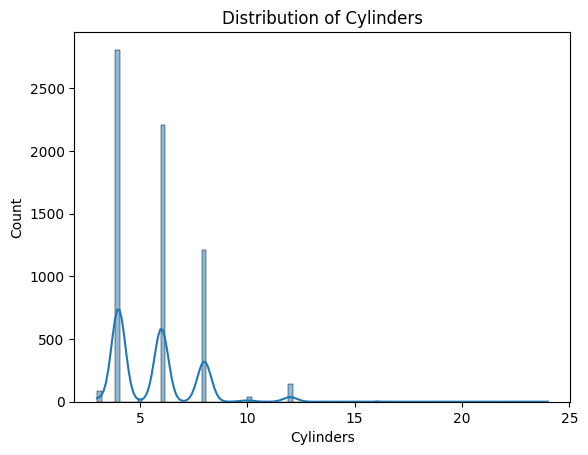

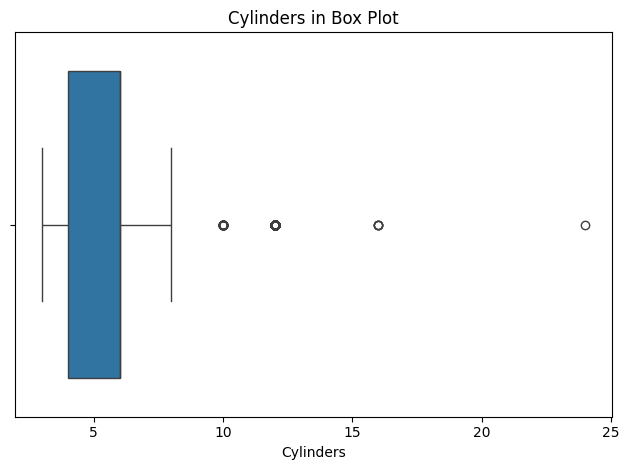

In [390]:
# Number of engine cylinders, associated with power and fuel consumption.
# Cylinders Statstic Summary
print(records['Cylinders'].describe())

# Visualising CO2 Emissions in histogram
sns.histplot(data=records, x='Cylinders' ,kde=True)
plt.title('Distribution of Cylinders')
plt.show()
plt.tight_layout()
print('\n')

# Visualising CO2 Emissions in Box Plot to see outliners
sns.boxplot(data=records, x='Cylinders',)
plt.title('Cylinders in Box Plot')
plt.tight_layout()
plt.show()
print('\n')

**Data Insights:**

Cylinders is a discrete variable with distinct peaks at 4, 6, and 8 cylinders, which together account for the vast majority of vehicles. A smaller cluster appears at 12 cylinders. The box plot confirms outliers at 10, 12, 16, and 24 cylinders, representing some rare vehicles configurations.


**Business Interpretation:**

The market is dominated by 4, 6, and 8-cylinder vehicles, reflecting standard consumer and commercial vehicle designs. Vehicles with 10 or more cylinders are niche products, likely luxury, high-performance, or heavy-duty vehicles that serve a very small segment of the market. This means the majority of CO2 emissions on Australian roads come from these three mainstream cylinder categories.

**Recommendations:**

AESC should advise government agencies to prioritise CO2 reduction strategies on the 4, 6, and 8-cylinder segments as a first step, as these represent the largest volume of vehicles on Australian roads and offer the greatest potential for overall emission reduction. At the same time, regulatory measures should also be introduced for vehicles with 10 or more cylinders to prevent manufacturers from shifting production toward higher-cylinder models to avoid mainstream emission standards, ensuring a comprehensive approach to sustainable transport


**Implications for ML Model Development:**

Cylinders behaves as a categorical-like discrete variable rather than a continuous one. The outliers (e.g., 16 and 24 cylinders) were retained in the dataset, as they represent real-world vehicle configurations rather than data errors. However, due to the very few data points in these categories, the model may produce less accurate predictions for these rare high-cylinder vehicles specifically, while maintaining reliable performance for the mainstream 4, 6, and 8-cylinder categories where training data is abundant



count   6485.00
mean       3.18
std        1.41
min        0.90
25%        2.00
50%        3.00
75%        3.70
max       16.80
Name: Engine Size, dtype: float64


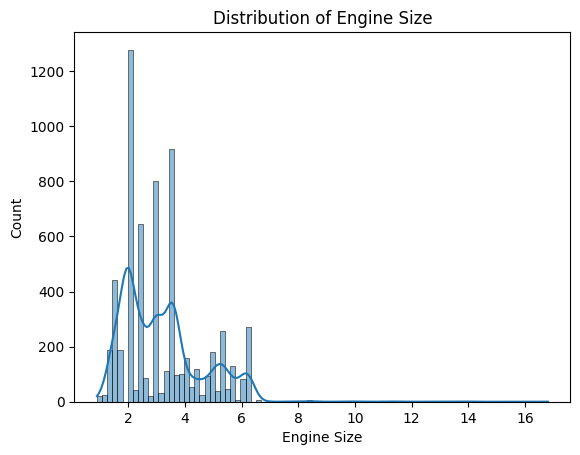

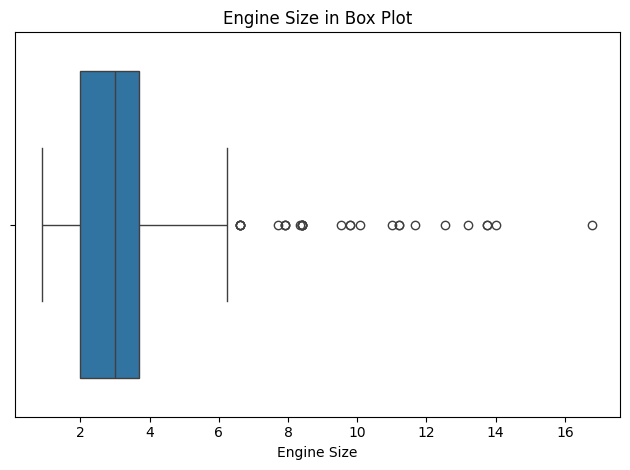

In [391]:
# Engine Size Engine displacement in litres, indicating engine capacity.
# Engine Size Statstic Summary

print(records['Engine Size'].describe())

# Visualising Engine Size in histogram
sns.histplot(data=records, x='Engine Size' ,kde=True)
plt.title('Distribution of Engine Size')
plt.show()
plt.tight_layout()
print('\n')

# Visualising Engine Size in Box Plot to see outliners
sns.boxplot(data=records, x='Engine Size',)
plt.title('Engine Size in Box Plot')
plt.tight_layout()
plt.show()
print('\n')

**Data Insights:**

Data Insight:
Engine Size is concentrated between 1L to 6L, with the most common sizes around 2L to 4L. The box plot identifies several outliers ranging from 7L to 16L, which represent a very small number of large-engine vehicles.


**Business Interpretation:**

The 2.0 to 4.0L engine segment dominates the market, reflecting standard passenger and commercial vehicle designs. Vehicles with engine sizes above 6.0L are likely high-performance or special-utility vehicles serving a very limited market segment. This suggests that emission reduction policies targeting the 2.0 to 4.0L range would affect the largest proportion of vehicles on Australian roads.


**Recommendations:**

AESC should advise government agencies to focus emission monitoring and regulatory efforts on the 2.0 to 6.0L engine range, where the greatest volume of vehicles is concentrated. For vehicles exceeding 6.0L, stricter emission standards or additional levies could be considered to discourage high-emission vehicle production and usage, supporting Australia's sustainable transport goals.

**Implications for ML Model Development:**

The outliers above 6L were retained in the dataset, as they represent real world large engine vehicles rather than data errors. However, due to the very limited number of data points in this range, the model may produce less accurate predictions for these large engine vehicles specifically, while maintaining reliable performance for the mainstream 1L to 6L range where the majority of training data is concentrated

### **Identify outliers for each Numercial variable**

In [392]:

# Calculate Q1, Q3, IQR  and numbers of outliers of Cylinders column
Q1_Cylinders = records['Cylinders'].quantile(0.25)
Q3_Cylinders = records['Cylinders'].quantile(0.75)
IQR_Cylinders = Q3_Cylinders - Q1_Cylinders
print ('Cylinders IQR:',IQR_Cylinders)

# Define Cylinders outliers boundaries
Cylinders_lower_bound = Q1_Cylinders - 1.5 * IQR_Cylinders
Cylinders_upper_bound = Q3_Cylinders + 1.5 * IQR_Cylinders

# Identify Cylinders outliers
Cylinders_outliers = records[(records['Cylinders'] < Cylinders_lower_bound) | (records['Cylinders'] > Cylinders_upper_bound)]
# Print the number of outliers and Q1, Q3 from Cylinders
print("Cylinders_lower_bound:", Cylinders_lower_bound)
print("Cylinders_upper_bound", Cylinders_upper_bound)
print("Number of outliers in 'Cylinders':", len(Cylinders_outliers))
print("----------------------------------------------------------------------------")

# ----------------------------------------------------------------------------

# Calculate Q1, Q3, IQR and numbers of outliers of Engine Size column
Q1_Engine_Size = records['Engine Size'].quantile(0.25)
Q3_Engine_Size = records['Engine Size'].quantile(0.75)
IQR_Engine_Size = Q3_Engine_Size - Q1_Engine_Size
print ('\nEngine_Size IQR:',IQR_Engine_Size)
# print into one demical
print(f'Engine Size IQR: {IQR_Engine_Size:.1f}')

# Define Cylinders outlier boundaries
Engine_Size_lower_bound = Q1_Engine_Size - 1.5 * IQR_Engine_Size
Engine_Size_upper_bound = Q3_Engine_Size + 1.5 * IQR_Engine_Size

# Identify Cylinders outliers
Engine_Size_outliers = records[(records['Engine Size'] < Engine_Size_lower_bound) | (records['Engine Size'] > Engine_Size_upper_bound)]
# Print the number of outliers and Q1, Q3 from Engine Size
print("Engine_Size_lower_bound:", Engine_Size_lower_bound)
print("Engine_Size_upper_bound",Engine_Size_upper_bound)
print("Number of outliers in 'Engine_Size':", len(Engine_Size_outliers))
print("----------------------------------------------------------------------------")
# ----------------------------------------------------------------------------

# Calculate Q1, Q3, IQR and numbers of outliers of CO2 Emissions column
Q1_CO2_Emissions = records['CO2 Emissions'].quantile(0.25)
Q3_CO2_Emissions = records['CO2 Emissions'].quantile(0.75)
IQR_CO2_Emissions = Q3_CO2_Emissions - Q1_CO2_Emissions
print ('\nCO2_Emissions IQR:',IQR_CO2_Emissions)

# Define CO2_Emissions outlier boundaries
CO2_Emissions_lower_bound = Q1_CO2_Emissions - 1.5 * IQR_CO2_Emissions
CO2_Emissions_upper_bound = Q3_CO2_Emissions + 1.5 * IQR_CO2_Emissions


# Identify CO2_Emissions outliers
CO2_Emissions_outliers = records[(records['CO2 Emissions'] < CO2_Emissions_lower_bound) | (records['CO2 Emissions'] > CO2_Emissions_upper_bound)]

# Print the number of outliers and Q1, Q3 from CO2 Emissions
print("CO2_Emissions_lower_bound:", CO2_Emissions_lower_bound)
print("CO2_Emissions_upper_bound",CO2_Emissions_upper_bound)
print("Number of outliers in 'CO2_Emissions':", len(CO2_Emissions_outliers))




Cylinders IQR: 2.0
Cylinders_lower_bound: 1.0
Cylinders_upper_bound 9.0
Number of outliers in 'Cylinders': 183
----------------------------------------------------------------------------

Engine_Size IQR: 1.7000000000000002
Engine Size IQR: 1.7
Engine_Size_lower_bound: -0.5500000000000003
Engine_Size_upper_bound 6.25
Number of outliers in 'Engine_Size': 29
----------------------------------------------------------------------------

CO2_Emissions IQR: 81.0
CO2_Emissions_lower_bound: 86.5
CO2_Emissions_upper_bound 410.5
Number of outliers in 'CO2_Emissions': 9


**Counting the lower or upper outliers for each Numercial columns**

In [393]:
# Count Cylinders data points below the lower bound and above the upper bound
Cyl_below_lower_bound = len(records[records['Cylinders'] < Cylinders_lower_bound])
Cyl_above_upper_bound = len(records[records['Cylinders'] > Cylinders_upper_bound])

print(f"Number of Cylinders lower outliers: {Cyl_below_lower_bound}")
print(f"Number of Cylinders upper outliers: {Cyl_above_upper_bound}")


# Count Engine Size data points below the lower bound and above the upper bound
EngS_below_lower_bound = len(records[records['Engine Size'] < Engine_Size_lower_bound])
EngS_above_upper_bound = len(records[records['Engine Size'] > Engine_Size_upper_bound])
print("\n----------------------------------------------------------------------------")
print(f"Number of Engine Size lower outliers: {EngS_below_lower_bound}")
print(f"Number of Engine Size upper outliers: {EngS_above_upper_bound}")

# Count CO2 Emissions data points below the lower bound and above the upper bound
CO2_below_lower_bound = len(records[records['CO2 Emissions'] < CO2_Emissions_lower_bound])
CO2_above_upper_bound = len(records[records['CO2 Emissions'] > CO2_Emissions_upper_bound])
print("\n----------------------------------------------------------------------------")
print(f"Number of CO2 Emissions lower outliers: {CO2_below_lower_bound}")
print(f"Number of CO2 Emissions upper outliers: {CO2_above_upper_bound}")


Number of Cylinders lower outliers: 0
Number of Cylinders upper outliers: 183

----------------------------------------------------------------------------
Number of Engine Size lower outliers: 0
Number of Engine Size upper outliers: 29

----------------------------------------------------------------------------
Number of CO2 Emissions lower outliers: 0
Number of CO2 Emissions upper outliers: 9




* The analysis indicates that the Cylinders variable exhibits a right-skewed distribution, with 183 outliers identified above the upper bound. This suggests a concentration of lower cylinder counts with a long tail towards higher values.


  *   **Mean** will be effected by the higher outliers
  *   Using **Median** will be better for filling the missing data



* The Engine Size variable shows a slightly right-skewed distribution, with 29 data points exceeding the upper bound, indicating that most vehicles have smaller engine sizes while a few have notably larger engines.
  *   **Mean** will be effected by the higher outliers
  *   Using **Median** will be better for filling the missing data


* CO2 Emissions demonstrates a near-normal distribution with only 9 outliers above the upper bound, suggesting that the majority of emission values are closely centred around the mean with minimal extreme values.
  *   **No Missing value** need to be treated













**Data insights:**

Outliers were identified using the IQR method (1.5 × IQR beyond Q1 and Q3) for all three numerical variables. Cylinders, Engine Size, and CO2 Emissions each contain a small number of outliers at the upper end, consistent with the right-skewed distributions observed earlier. These outliers were retained in the dataset, as outliers naturally exist in real-world data and do not necessarily indicate data errors.

### **Data Cleansing for Numerical data**

In [394]:
#Filling null numerical data with median for Cylinders as the data is right skewed
records['Cylinders'].fillna(records['Cylinders'].median(),inplace=True)

#Filling null numerical data with median for Engine Size as the data is slightly right-skewed
records['Engine Size'].fillna(records['Engine Size'].median(),inplace=True)



# Printting New dataset
# ******* Cylinders & Engine Size should show 0 **********************
records.isnull().sum()



/tmp/ipykernel_20240/3046136269.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  records['Cylinders'].fillna(records['Cylinders'].median(),inplace=True)
/tmp/ipykernel_20240/3046136269.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

,0
Dealer_ID,0
Dealer_State,0
Make,0
Vehicle Category,0
Vehicle Colour,200
Listing Month,0
Transmission Type,267
Fuel Type,0
Cylinders,0
Engine Size,0


**Data insights:**

Missing values in Cylinders and Engine Size were replaced with the median, as both distributions are right-skewed and the median is less affected by outliers than the mean.

###**Visualising Numerical Data**

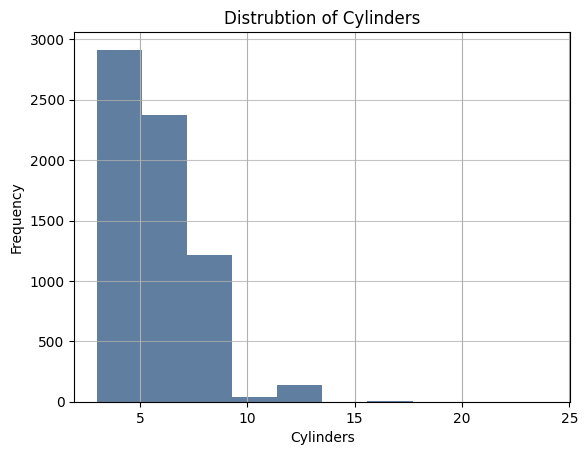

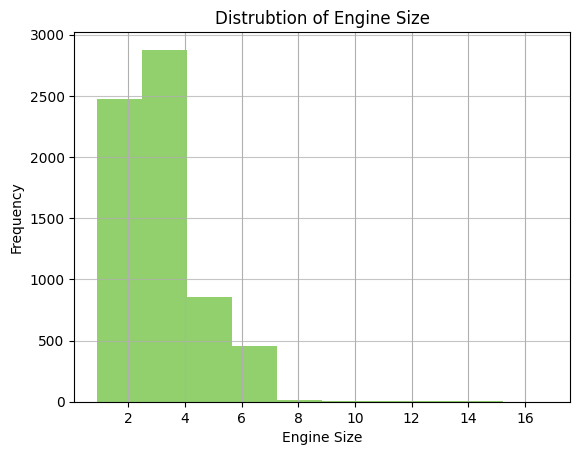

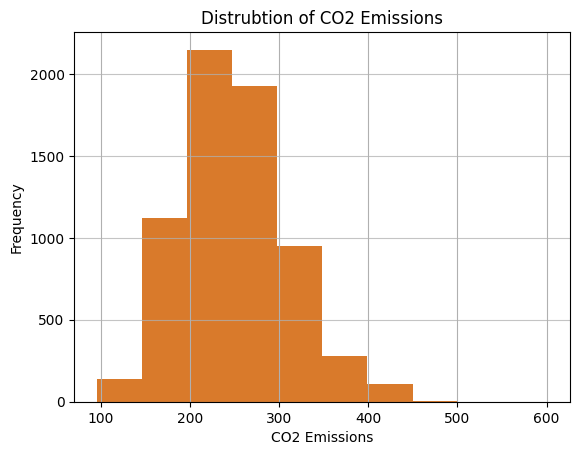

In [395]:
#Visualise numerical variable using histrograms
# -------------------------------Cylinders (Blue) ---------------------------------------
records['Cylinders'].hist()

#Specify the histogram
records['Cylinders'].plot.hist(grid=True, bins=10, rwidth=2, color='#607e9f')
plt.title('Distrubtion of Cylinders')
plt.xlabel('Cylinders')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# -------------------------------Engine Size (Green) ---------------------------------------

records['Engine Size'].hist()
#Specify the histogram
records['Engine Size'].plot.hist(grid=True, bins=10, rwidth=2, color='#91D06C')
plt.title('Distrubtion of Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
print('\n')
plt.show()


# -------------------------------CO2 Emissions (Brown) ---------------------------------------
records['CO2 Emissions'].hist()
#Specify the histogram
records['CO2 Emissions'].plot.hist(grid=True, bins=10, rwidth=2, color='#D97A2B')
plt.title('Distrubtion of CO2 Emissions')
plt.xlabel('CO2 Emissions')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
print('\n')
plt.show()




**Data Insights:**

After data cleaning, all three numerical variables (Cylinders, Engine Size, and CO2 Emissions) remain right-skewed. Cylinders is concentrated at 4, 6, and 8; Engine Size is concentrated between 1L to 4L; and CO2 Emissions peaks around 200–250 g/km. The overall shape of each distribution is consistent with the pre-cleaning analysis, confirming that the median imputation did not distort the original data patterns.

**Business Interpretation:**

The consistency between pre- and post-cleaning distributions indicates that the dataset remains representative of the Australian vehicle market after preprocessing. The majority of vehicles continue to fall within mainstream specifications, reinforcing the earlier finding that emission reduction efforts should target these dominant segments.

**Recommendations:**

As the cleaned data confirms the same market patterns, AESC can proceed with confidence that the analysis and any subsequent modelling are based on a reliable and representative dataset. No further data adjustments are required at this stage.

**Implications for ML Model Development:**

The preserved distribution shapes after cleaning confirm that the imputation strategy did not introduce bias into the training data. The right-skewed nature of all three variables should still be considered during model evaluation, as predictions may be less reliable at the extreme high end of each variable.

##**⬆️ Explore treated Numerical Data**

In [396]:
print('Cylinders	 mean: ', (records['Cylinders'].mean()))
print('Cylinders	 meadian: ', (records['Cylinders'].median()))
print('Cylinders	 min: ', (records['Cylinders'].min()))
print('Cylinders	 max: ', (records['Cylinders'].max()))
print('Cylinders	 std: ', (records['Cylinders'].std()))

# Engine Size data summary
print('-------------------------------------------')
print('Engine Size	 mean: ', (records['Engine Size'].mean()))
print('Engine Size	 meadian: ', (records['Engine Size'].median()))
print('Engine Size	 min: ', (records['Engine Size'].min()))
print('Engine Size	 max: ', (records['Engine Size'].max()))
print('Engine Size	 std: ', (records['Engine Size'].std()))
print('-------------------------------------------')

# CO2 Emissions
print('CO2 Emissions	 mean: ', (records['CO2 Emissions'].mean()))
print('CO2 Emissions	 meadian: ', (records['CO2 Emissions'].median()))
print('CO2 Emissions	 min: ', (records['CO2 Emissions'].min()))
print('CO2 Emissions	 max: ', (records['CO2 Emissions'].max()))
print('CO2 Emissions	 std: ', (records['CO2 Emissions'].std()))

Cylinders	 mean:  5.639192221391174
Cylinders	 meadian:  6.0
Cylinders	 min:  3.0
Cylinders	 max:  24.0
Cylinders	 std:  1.8281875844957665
-------------------------------------------
Engine Size	 mean:  3.1769214659685865
Engine Size	 meadian:  3.0
Engine Size	 min:  0.9
Engine Size	 max:  16.8
Engine Size	 std:  1.392208583596873
-------------------------------------------
CO2 Emissions	 mean:  250.73432311144353
CO2 Emissions	 meadian:  246.0
CO2 Emissions	 min:  96.0
CO2 Emissions	 max:  601.5
CO2 Emissions	 std:  58.70982136690987


**Data Insight:**

After data cleaning, Cylinders has a mean of 5.63 and a median of 6.0, ranging from 3 to 24.

Engine Size has a mean of 3.18 and a median of 3.0, ranging from 0.9 to 16.8.

CO2 Emissions has a mean of 250.7 g/km and a median of 246.0 g/km, ranging from 96 to 601.5.

Across all three variables, the mean and median values are close to each other, indicating that the imputation did not significantly alter the original data distribution.

###**Bivareate numerical data analysis**

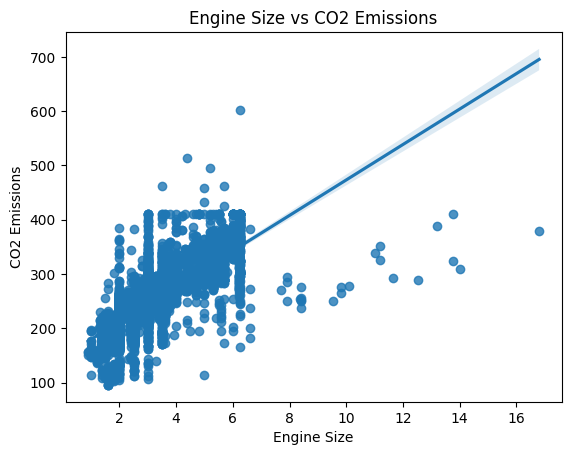

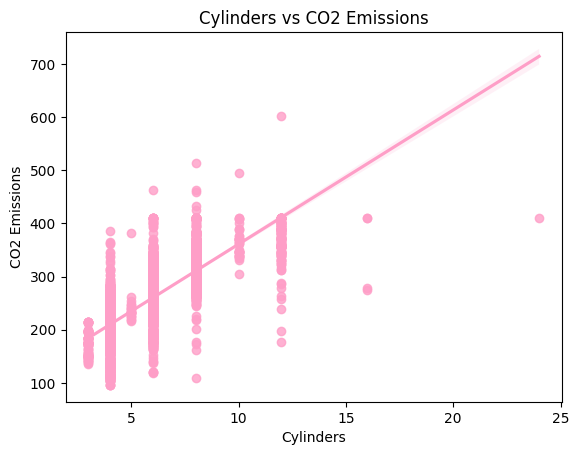

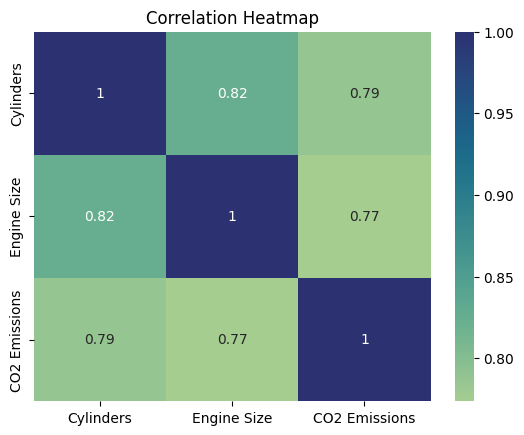

In [397]:
# Regression plot
# Using Regression plot, and correaltion to discover the pattern with CO2 Emissions
sns.regplot(data=records, x='Engine Size', y='CO2 Emissions')
plt.title('Engine Size vs CO2 Emissions')
plt.show()
print('\n')

sns.regplot(data=records, x='Cylinders', y='CO2 Emissions',color='#FE9EC7')
plt.title('Cylinders vs CO2 Emissions')
plt.show()
print('\n')


# Correlation heatmap
sns.heatmap(records[['Cylinders', 'Engine Size', 'CO2 Emissions']].corr(),
            annot=True, cmap='crest')
plt.title('Correlation Heatmap')
plt.show()

**Data Insight:**

Both scatter plots show a positive linear relationship between CO2 Emissions and the two numerical predictors. The correlation heatmap confirms this: Cylinders has a correlation of 0.79 with CO2 Emissions, and Engine Size has a correlation of 0.77. Additionally, Cylinders and Engine Size are highly correlated with each other at 0.82, indicating potential multicollinearity between the two predictors.

**Business Interpretation:**

Vehicles with larger engines and more cylinders tend to produce higher CO2 emissions. This is consistent with existing research, which identifies engine size and cylinder count as primary contributors to vehicle CO2 emissions (Zubair et al., 2025; Al-Nefaie & Aldhyani, 2023). The strong relationship between these vehicle specifications and emissions suggests they are key drivers of CO2 output on Australian roads.

**Recommendations:**

AESC should advise government agencies that engine size and cylinder count are strong indicators of CO2 emissions. CO2 Emission estimation could use these vehicle specifications as a practical proxy for predicting emissions when direct measurements are unavailable.

**Implications for ML Model Development:**

Both Cylinders and Engine Size show strong correlations with CO2 Emissions, supporting their inclusion as features in the regression model. However, the high correlation between Cylinders and Engine Size (0.82) indicates multicollinearity, which may affect the stability of model coefficients. This should be monitored during model evaluation.


## **⬇️ Initial EDA for Categorical Data**

In [398]:
print(records.isnull().sum())
print('\n')
print((records.isnull().sum() / len(records) * 100).round(1).astype(str) + '%')

Dealer_ID              0
Dealer_State           0
Make                   0
Vehicle Category       0
Vehicle Colour       200
Listing Month          0
Transmission Type    267
Fuel Type              0
Cylinders              0
Engine Size            0
CO2 Emissions          0
dtype: int64


Dealer_ID            0.0%
Dealer_State         0.0%
Make                 0.0%
Vehicle Category     0.0%
Vehicle Colour       3.0%
Listing Month        0.0%
Transmission Type    4.0%
Fuel Type            0.0%
Cylinders            0.0%
Engine Size          0.0%
CO2 Emissions        0.0%
dtype: object


**Data Insight:**

After cleaning numerical data, two categorical columns still contain missing values: Vehicle Colour (200 missing) and Transmission Type (267 missing, 4% over the entire dataset). All numerical variables (Cylinders, Engine Size, and CO2 Emissions) have been fully transformed with no remaining nulls. Vehicle Colour was decided excluced from the dataset, as colour is not expected to have a meaningful impact on CO2 emissions. The remaining missing values in Transmission Type will require a different transforming strategy such as mode replacement with dummy coding.



### **Data Cleansing for Categorical data**

In [399]:
#Filling mode null value for Transmission Type
#As total null values are 267 over entire dataset
records['Transmission Type'].fillna(records['Transmission Type'].mode()[0], inplace=True)

# ========== Vehicle Colour itself wont effect CO2 Emissions, here we won't do any further treatmnet and will drop the column in the further analysis ======================
# ========= Reference is attached in the report=====================



# Printting all null values in dataset
# ******* Transmission Type should show 0 **********************
records.isnull().sum()


/tmp/ipykernel_20240/1944550070.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  records['Transmission Type'].fillna(records['Transmission Type'].mode()[0], inplace=True)


,0
Dealer_ID,0
Dealer_State,0
Make,0
Vehicle Category,0
Vehicle Colour,200
Listing Month,0
Transmission Type,0
Fuel Type,0
Cylinders,0
Engine Size,0


**Data Insight:**

After imputation, Transmission Type now contains zero missing values, confirming that the mode replacement was applied successfully. Vehicle Colour still retains 200 missing values; however, this column will be dropped in the subsequent analysis as vehicle colour is not expected to influence CO2 emissions.

In [400]:
records['Transmission Type']


,Transmission Type
0,AM8
1,AM7
2,A8
3,A6
4,AS5
...,...
6680,AS6
6681,AS8
6682,A9
6683,AS8


###**Transforming Categorial data**

**Grouping by Transmission Type into two groups**

In [401]:
# Grouping by Transmission Type into two groups , as now we have too many types in Transmissions
# New sorted Transmission Type named Transmission_Group

# This way we have the origianl data and new sorted data for reference

def classify_transmission(t):
    if pd.isna(t):
        return np.nan
    elif t.startswith('M'):
        return 'Manual'
    else:
        return 'Automatic'

records['Transmission_Group'] = records['Transmission Type'].apply(classify_transmission)
print(records['Transmission_Group'].value_counts())



Transmission_Group
Automatic    5649
Manual       1036
Name: count, dtype: int64


**Data Insight:**

The original Transmission Type column contains multiple subcategories (e.g., AM8, A5, AS5, AV6), which would be difficult to analyse individually. To simplify the analysis, transmission types were grouped into two broader categories: Automatic and Manual. Entries starting with 'M' were classified as Manual, and all others were classified as Automatic. The resulting distribution shows that Automatic (5,649) is the dominant category, followed by Manual (1,036).

**Visualising Transmission Type total counts**

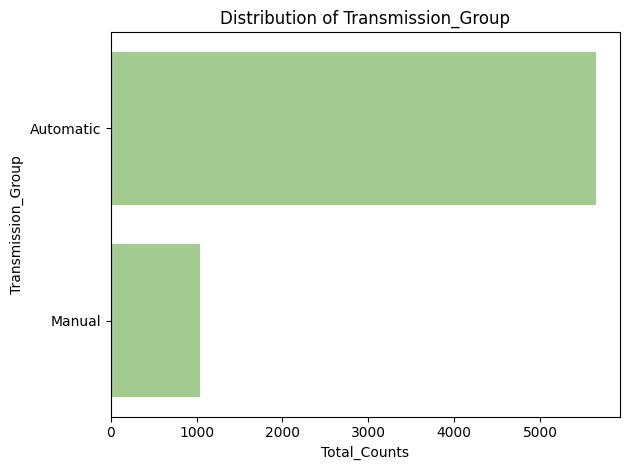

Transmission_Group
Automatic    84.5%
Manual       15.5%
Name: proportion, dtype: object


In [402]:
# Visualising Transmission_Group total counts
plt.figure()
sns.countplot(data=records, y='Transmission_Group', color='#A0D585')
plt.title('Distribution of Transmission_Group')
plt.xlabel('Total_Counts')
plt.tight_layout()
plt.show()

# Calculate percentage of each Transmission_Group
# Calculate percentage of each Transmission_Group
print((records['Transmission_Group'].value_counts(normalize=True) * 100).map('{:.1f}%'.format))

**Data Insight:**

Automatic transmission vehicles dominate the dataset with 5,649 entries, compared to 1,036 for Manual. Approximately 84.5% of vehicles in the dataset are Automatic.

**Business Interpretation:**

The strong dominance of automatic transmission vehicles reflects current consumer preferences and market trends in Australia, where automatic vehicles have become the standard choice for most buyers. Manual transmission vehicles represent a declining but still present segment of the market.

**Recommendations:**

AESC should advise government agencies to prioritise automatic transmission vehicles as the first target for CO2 reduction policies, as this segment's dominant market share means emission improvements would be seen most quickly. However, manual transmission vehicles must also be subject to the same emission standards to prevent manufacturers from exploiting regulatory loopholes by shifting production toward manual models or some hybrid models

**Implications for ML Model Development:**

The imbalanced distribution between the two categories means the model will have significantly more training data for automatic vehicles. Predictions for manual transmission vehicles may be less reliable due to the smaller sample size, and this should be considered when interpreting model results.

###**Bivariate Transmission vs CO2**

**Transmission Type vs CO2 Emissions**

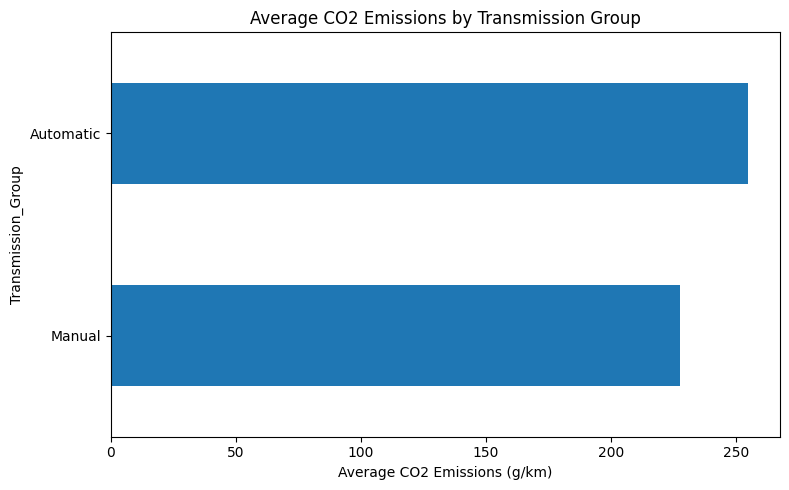

In [403]:

plt.figure(figsize=(8, 5))
records.groupby('Transmission_Group')['CO2 Emissions'].mean().sort_values().plot(kind='barh')
plt.title('Average CO2 Emissions by Transmission Group')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.tight_layout()
plt.show()

**Data Insight:**

Automatic transmission vehicles produce a slightly higher average CO2 emission (approximately 255 g/km) compared to Manual vehicles (approximately 225 g/km). The difference is noticeable but not drastic.

**Business Interpretation:**

The higher average emissions from automatic vehicles are likely due to their association with larger, heavier vehicles and higher engine capacities. Combined with their dominant market share, automatic vehicles contribute the most to overall CO2 output

**Recommendations:**

Reducing CO2 emissions results from automatic transmission vehicles would have the most significant impact, as they not only produce higher average emissions but also represent the vast majority of vehicles on Australian roads. Even a small reduction per vehicle would lead to substantial overall emission savings at scale.

**Implications for ML Model Development:**

Transmission type shows a measurable difference in CO2 emissions between the two categories, supporting its inclusion as a feature in the regression model

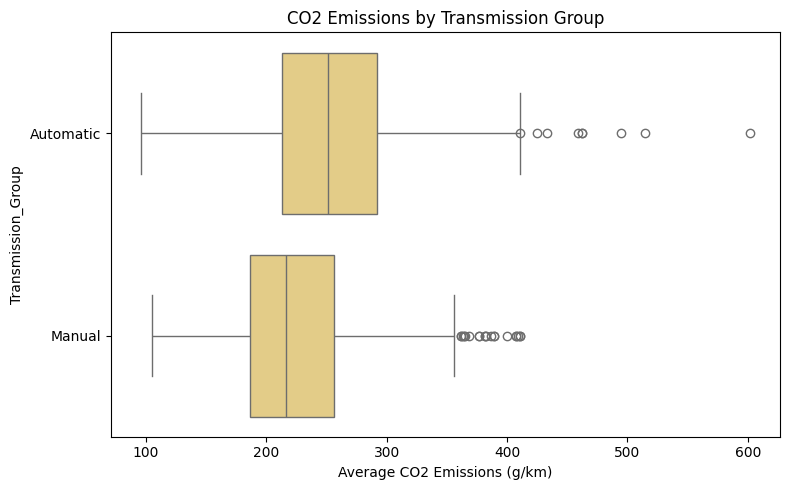

In [404]:
plt.figure(figsize=(8, 5))
plt.title('CO2 Emissions by Transmission Group')
sns.boxplot(data=records, x='CO2 Emissions', y='Transmission_Group',color='#F2D479')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.tight_layout()
plt.show()

**Data Insight:**

The box plot confirms that automatic vehicles have a wider spread of CO2 emissions and a higher median compared to manual vehicles. Automatic vehicles also show more outliers extending up to 600 g/km, while manual vehicle outliers are clustered around 350–400 g/km.

**Business Interpretation:**

The wider emission range for automatic vehicles suggests greater variation in vehicle types within this category, from fuel-efficient models to high-performance or heavy-duty vehicles. Manual vehicles show a more consistent and generally lower emission profile.

**Recommendations:**

AESC should highlight to government agencies that automatic transmission vehicles not only produce higher emissions on average but also contain the most extreme high-emission outliers. Targeted policies for the highest-emitting automatic vehicles could deliver significant emission reductions.

**Implications for ML Model Development:**

The wider spread and greater number of outliers in the automatic category may introduce more variability in model predictions for this group. The model may predict manual vehicle emissions more consistently due to their narrower distribution.

###**Bivariate Dealer_State vs CO2**

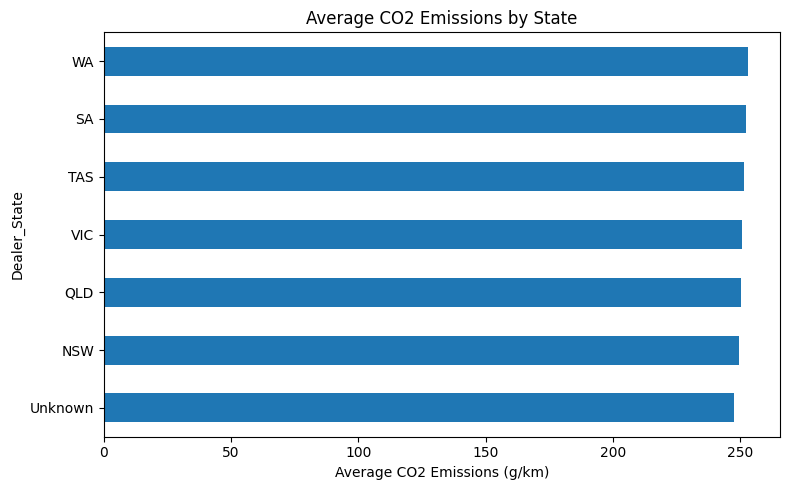

In [405]:
# Visualising CO2 Emissions by grouping state together
# Taking each state Mean for CO2 Emissions

plt.figure(figsize=(8, 5))
records.groupby('Dealer_State')['CO2 Emissions'].mean().sort_values().plot(kind='barh')
plt.title('Average CO2 Emissions by State')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.tight_layout()
plt.show()

**Data Insight:**

The average CO2 emissions across all states are very similar, ranging from approximately 245 to 255 g/km, with minimal variation between states. An "Unknown" category was also identified in the Dealer_State column, indicating some records have missing or unrecorded state information

**Business Interpretation:**
The consistency of average emissions across states suggests that CO2 emissions are primarily driven by vehicle specifications (e.g., engine size, cylinders) rather than geographic location.

**Recommendations:**
Since emissions do not vary significantly by state, AESC should advise government agencies that emission reduction policies can be applied nationally rather than requiring state-specific strategies. The **Unknown** records should be flagged for data quality improvement in future data collection.

**Implications for ML Model Development:**

The minimal variation in CO2 emissions across states suggests that Dealer_State may have limited predictive value for the regression model. This should be considered during feature selection to avoid including low-impact variables that add noise without improving model accuracy

**Visualising Dealer State total counts**

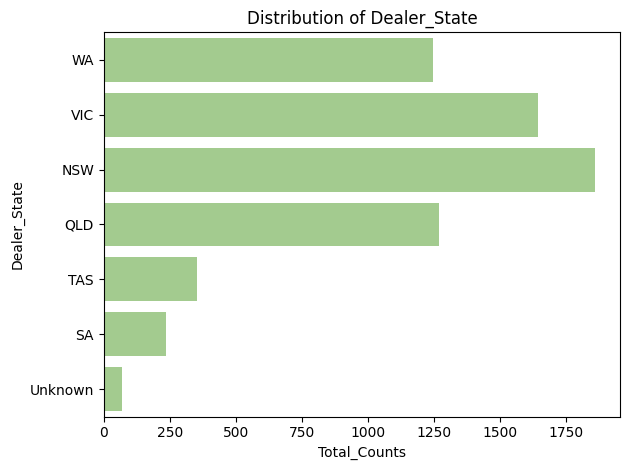

In [406]:
# Visualising Dealer_State total counts
plt.figure()
sns.countplot(data=records, y='Dealer_State', color='#A0D585')
plt.title('Distribution of Dealer_State')
plt.xlabel('Total_Counts')
plt.tight_layout()
plt.show()

**Data Insight:**

NSW has the highest number of dealer listings (approximately 1,850), followed by VIC (approximately 1,650) and QLD (approximately 1,250). TAS, SA, and WA have significantly fewer listings, and the "Unknown" category contains a small number of records (approximately lessthan 100).

**Business Interpretation:**

The distribution of dealers aligns with Australia's population distribution, with the most populated states (NSW, VIC, QLD) having the most listings. This suggests the dataset is representative of the broader Australian vehicle market. The small "Unknown" group is unlikely to significantly impact overall analysis.

**Recommendations:**

AESC should note that insights drawn from this dataset are most robust for NSW, VIC, and QLD due to their larger sample sizes. Any state-specific recommendations for smaller states (TAS, SA) should be made with caution given the limited data available.

**Implications for ML Model Development:**

The uneven distribution of data across states further supports the earlier finding that Dealer_State has limited value as a predictive feature. If included in the model, the underrepresented states may not have sufficient data for reliable predictions.

**Counting Unknow value in Dealer_State**

In [407]:
# print total record counts in Dealer_State column
print(f'Total record counts for Dealer_State: {total_sample_size}')


# To get total Unknown value Percentage in Dealer_State over the entire dataset
total_dealer_unknown_count = records[records['Dealer_State'] == 'Unknown'].shape[0]

total_dealer_unknown_pct = total_dealer_unknown_count / total_sample_size * 100




# Printing Total Unknown counts and formatting into 2 decimal place
# Using print(f'{total_dealer_unknown_count}') to print variable

print(f'Total Unknown counts for Dealer_State: {total_dealer_unknown_count}')
print(f'Percentage: {total_dealer_unknown_pct:.2f}%')

Total record counts for Dealer_State: 6685
Total Unknown counts for Dealer_State: 69
Percentage: 1.03%


As the result shows, only **1.03%** of the data contains "Unknown" values in the Dealer_State column. Given this is a very small proportion, and since Dealer_State is a categorical variable where imputing with mode may not accurately reflect the true state, we have decided to drop these records. **Removing 69 rows out of 6,685** is unlikely to have a significant impact on the overall data quality or analysis outcomes.

**Deleting 69 records that contain Unknown value  in Dealer_State column**



In [408]:
# overwirte records that in ['Dealer_State'] is not 'Unknown'
records = records[records['Dealer_State'] != 'Unknown']
records_drop_unknown_state = total_sample_size - total_dealer_unknown_count
print(f'After Removing Unknown State total records should be: {records_drop_unknown_state}')

# To confirm if the total records are correct
print(f'Total records after removing Unknown State: {records.shape[0]}')

After Removing Unknown State total records should be: 6616
Total records after removing Unknown State: 6616


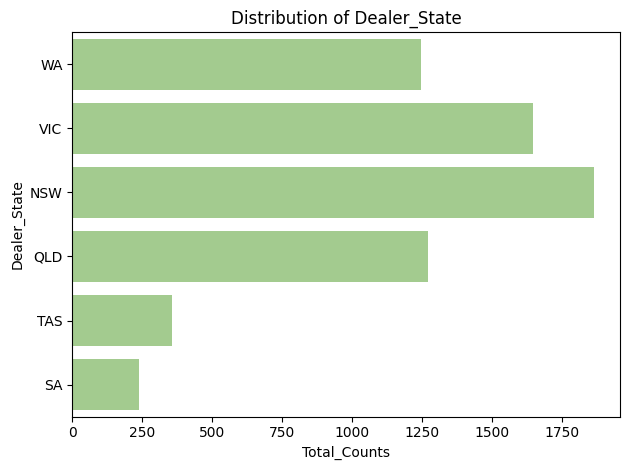

In [409]:
# Visualising Cleaned Dealer_State total counts
plt.figure()
sns.countplot(data=records, y='Dealer_State', color='#A0D585')
plt.title('Distribution of Dealer_State')
plt.xlabel('Total_Counts')
plt.tight_layout()
plt.show()

**Data Insight:**

After removing the "Unknown" records, the dataset contains six Australian states. NSW remains the largest contributor (approximately 1,850 listings), followed by VIC, QLD, and WA, with TAS and SA having the fewest listings.

**Business Interpretation:**

The cleaned distribution continues to reflect Australia's population spread, confirming the dataset is representative of the national vehicle market. Removing the "Unknown" records improves data quality without significantly reducing the overall sample size.

**Recommendations:**

With the "Unknown" records removed, AESC can now report state-level findings with greater confidence. However, insights for SA and TAS should still be interpreted with caution due to their smaller sample sizes.

**Implications for ML Model Development:**

Removing the "Unknown" category eliminates a source of noise in the data. The remaining state-level distribution remains uneven. Combined with the earlier finding that average CO2 emissions are very similar across all states, Dealer_State was excluded as a feature in the regression model, as it is unlikely to contribute meaningful predictive power.


### **Dealer_ID Comparision**


['D056', 'D032', 'D046', 'D018', 'D015']


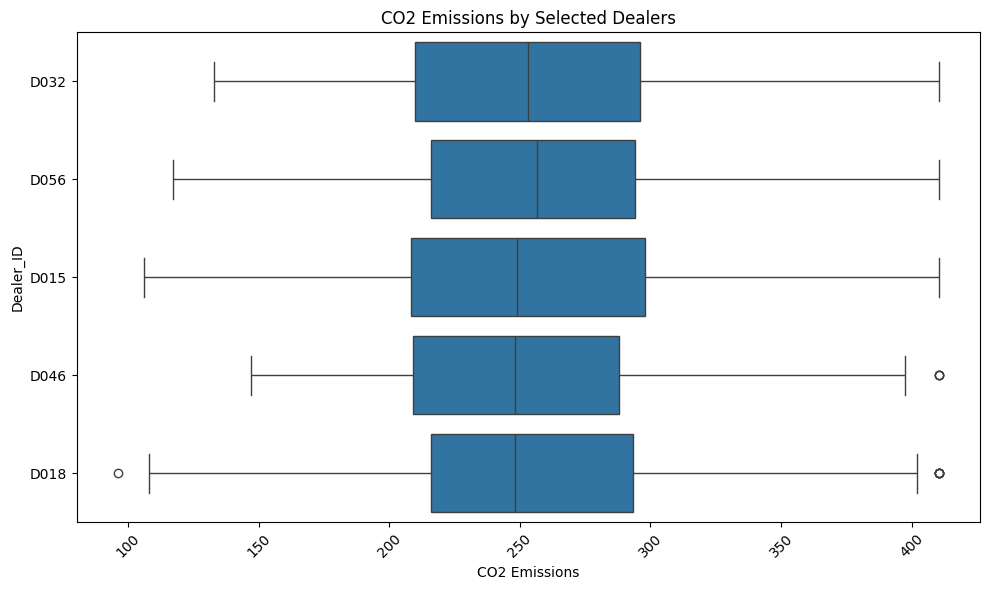

  Dealer_ID Dealer_State  Avg_CO2_Emissions
1      D018          NSW             257.39
4      D056           WA             255.28
2      D032          TAS             254.48
0      D015          VIC             251.89
3      D046           WA             251.79


In [410]:
# Find top 5 dealers by listing count
top_dealers = records['Dealer_ID'].value_counts().head(5).index.tolist()
print(top_dealers)

# Filter data for top 5 dealers
dealer_subset = records[records['Dealer_ID'].isin(top_dealers)]

# Box plot comparing CO2 emissions across dealers
plt.figure(figsize=(10, 6))
# sns.boxplot(data=dealer_subset, x='Dealer_ID', y='CO2 Emissions')
sns.boxplot(data=dealer_subset, x='CO2 Emissions', y='Dealer_ID')
plt.title('CO2 Emissions by Selected Dealers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mean comparison with state, sorted by CO2 Emissions
dealer_summary = dealer_subset.groupby(['Dealer_ID', 'Dealer_State'])['CO2 Emissions'].mean().reset_index()
dealer_summary.columns = ['Dealer_ID', 'Dealer_State', 'Avg_CO2_Emissions']
dealer_summary = dealer_summary.sort_values('Avg_CO2_Emissions', ascending=False)
print(dealer_summary)

**Data Insight:**

The top 5 dealers by listing volume show similar average CO2 emissions ranging from 252 to 257 g/km. However, their distributions differ: D015 (VIC) and D032 (TAS) show the widest IQR, while D056 and D046 (both WA) have a narrower spread. D018 (NSW) and D046 (WA) each have outliers reaching approximately 400 g/km, and D018 also has a low-end outlier near 100 g/km.


**Business Interpretation:**


The similar median emissions across dealers suggest that vehicle inventory mix is broadly consistent nationwide. However, the wider spread at D015 and D032 indicates these dealers stock a more diverse range of vehicles, from fuel-efficient models to high-emission ones. The outliers at D018 and D046 may reflect the occasional sale of high-performance or heavy-duty vehicles. These differences are likely driven by each dealer's product mix and local market demand rather than geographic factors, suggesting that Dealer_ID has minimal impact on CO2 emissions.

**Recommendations:**

AESC should advise government agencies that emission variation is primarily driven by the types of vehicles each dealer sells, not by dealer location. Dealers with wider emission ranges, such as D015 and D032, could be encouraged to promote lower-emission vehicle options to shift their overall emission profile downward.

**Implications for ML Model Development:**

The similar emission patterns across dealers further confirms that Dealer_ID would add minimal predictive value to the regression model and was therefore excluded from feature selection.

In [414]:
records['Vehicle Category']


,Vehicle Category
0,FULL-SIZE
1,SUBCOMPACT
2,PICKUP TRUCK - STANDARD
3,PICKUP TRUCK - STANDARD
4,SUV - STANDARD
...,...
6680,SUV - SMALL
6681,MID-SIZE
6682,MID-SIZE
6683,TWO-SEATER


### **Grouping by Vehicle Category**

In [415]:
# Grouping by Vehicle Category into new groups, Vehicle Category column contains numerous subcategories too hard to analysis
# We grouping Vehicles by types and sizes
# New sorted Vehicle Category named Vehicle_Group
# This way we have the origianl data and new sorted data for reference



def classify_vehicle(v):
    if v in ['MINICOMPACT', 'SUBCOMPACT', 'TWO-SEATER']:
        return 'Car (S)'
    elif v in ['COMPACT', 'MID-SIZE']:
        return 'Car (M)'
    elif v in ['FULL-SIZE']:
        return 'Car (L)'
    elif v in ['PICKUP TRUCK - SMALL']:
        return 'Pickup (S)'
    elif v in ['PICKUP TRUCK - STANDARD']:
        return 'Pickup (L)'
    elif v in ['SUV - SMALL']:
        return 'SUV (S)'
    elif v in ['SUV - STANDARD']:
        return 'SUV (L)'
    elif v in ['MINIVAN', 'VAN - CARGO']:
        return 'Van'
    elif v in ['VAN - PASSENGER']:
        return 'Van (Heavy Duty)'
    elif v in ['SPECIAL PURPOSE VEHICLE']:
        return 'Special Purpose'
    elif v in ['STATION WAGON - SMALL', 'STATION WAGON - MID-SIZE']:
        return 'Sedan Wagon'
    else:
        return v


records['Vehicle_Group'] = records['Vehicle Category'].apply(classify_vehicle)
print(records['Vehicle_Group'].value_counts())






Vehicle_Group
Car (M)             1939
Car (S)             1248
SUV (S)             1083
SUV (L)              651
Car (L)              569
Pickup (L)           482
Sedan Wagon          276
Pickup (S)           145
Van                   97
Special Purpose       67
Van (Heavy Duty)      59
Name: count, dtype: int64


**Data insight:**

The original Vehicle Category column contains numerous subcategories, making individual analysis impractical. To simplify, these were grouped into 11 broader Vehicle Groups based on vehicle type and size.

For example, MINICOMPACT, SUBCOMPACT, and TWO-SEATER were grouped as Car (S), while COMPACT and MID-SIZE became Car (M).

The resulting distribution shows that Car (M) is the largest group (1,939), followed by Car (S) (1,248) and SUV (S) (1,083), while Van (Heavy Duty) (59) and Special Purpose (67) have the fewest records.

### **Visualising Vehicle_Group total counts**

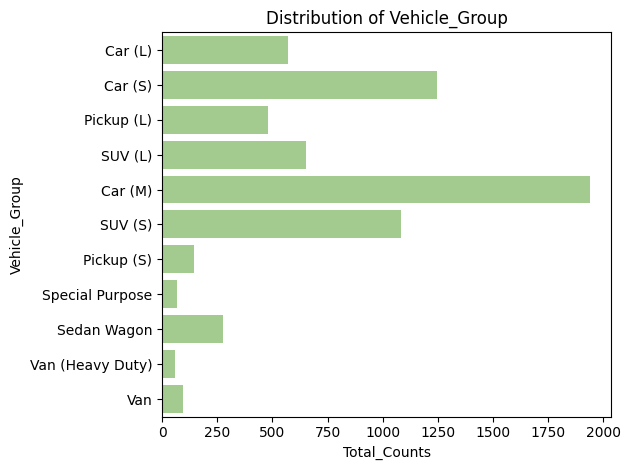

In [416]:
# Visualising Vehicle_Group total counts
plt.figure()
sns.countplot(data=records, y='Vehicle_Group', color='#A0D585')
plt.title('Distribution of Vehicle_Group')
plt.xlabel('Total_Counts')
plt.tight_layout()
plt.show()

**Data Insight:**

Car (M) has the most listings (approximately 1,939), followed by Car (S) (1,248) and SUV (S) (1,083). Commercial and specialty vehicles such as Van (Heavy Duty) (59), Special Purpose (67), and Van (97) have significantly fewer records.

**Business Interpretation:**

The dataset reflects a market dominated by mid-size and small passenger cars and SUVs, which is consistent with typical Australian consumer preferences. Commercial and heavy-duty vehicles represent a small but distinct segment of the market.

**Recommendations:**

AESC should advise government agencies that emission reduction policies targeting mid-size cars, small cars, and small SUVs would cover the largest proportion of vehicles. Separate emission standards may be needed for commercial vehicles (Vans, Pickups) given their different usage patterns and emission profiles.

**Implications for ML Model Development:**

The significant imbalance across vehicle groups means the model will have abundant training data for Car (M), Car (S), and SUV (S), but very limited data for Van (Heavy Duty), Special Purpose, and Van. Predictions for these groups may be less reliable.

###**Bivariate Vehicle_Group vs CO2**

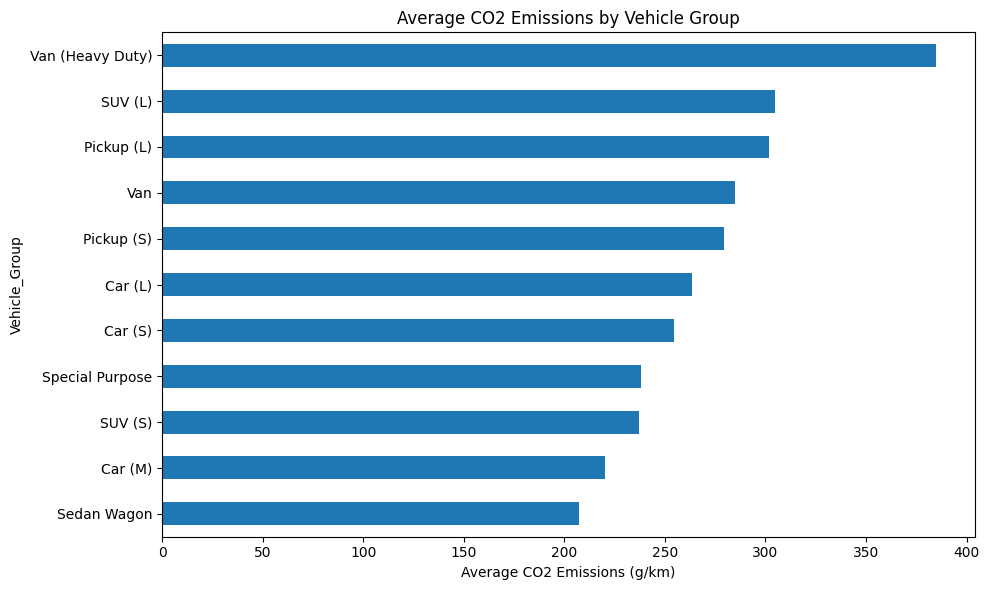

In [417]:
# Visualising CO2 Emissions by Vehicle_Group

plt.figure(figsize=(10, 6))
records.groupby('Vehicle_Group')['CO2 Emissions'].mean().sort_values().plot(kind='barh')
plt.title('Average CO2 Emissions by Vehicle Group')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.tight_layout()
plt.show()

**Data Insight:**

Van (Heavy Duty) produces the highest average CO2 emissions at approximately 390 g/km, followed by SUV (L) and Pickup (L) at around 300 g/km. Sedan Wagon and Car (M) produce the lowest average emissions at approximately 210–225 g/km. There is a clear trend where commercial and utility vehicle types emit more CO2 than passenger vehicles.

**Business Interpretation:**

Vehicle category is a strong indicator of CO2 emissions. Larger vehicles such as heavy-duty vans, large SUVs, and large pickups produce significantly more emissions due to their greater weight and larger engines. The most popular categories — Car (M) and Car (S) — produce relatively lower emissions, which is a positive finding given their dominant market share.

**Recommendations:**

AESC should advise government agencies to implement tiered emission standards based on vehicle category. While the high-volume Car (M) and Car (S) segments offer the greatest scale for emission savings, the high-emission categories such as Van (Heavy Duty), SUV (L), and Pickup (L) should face stricter emission limits to prevent their disproportionate contribution to overall CO2 output.

**Implications for ML Model Development:**

The clear variation in average CO2 emissions across vehicle groups confirms that Vehicle Group is a valuable predictive feature for the regression model. Its inclusion should help the model differentiate emission levels based on vehicle type and improve overall prediction accuracy.

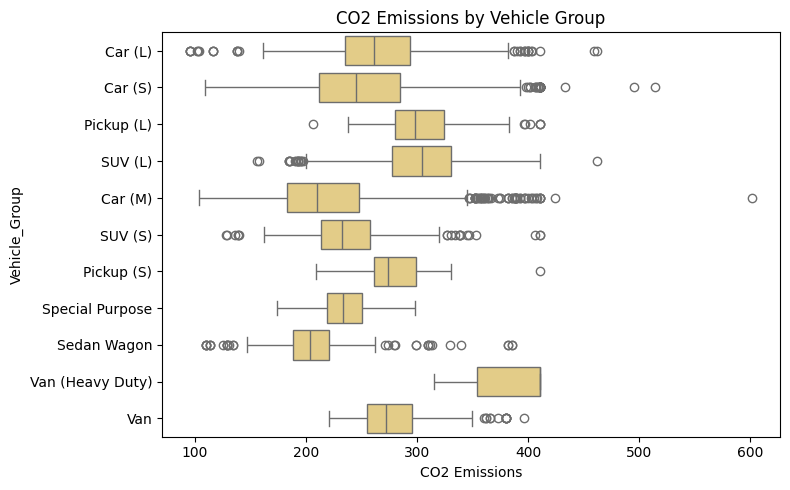

In [418]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=records, x='CO2 Emissions', y='Vehicle_Group',color='#F2D479')
plt.title('CO2 Emissions by Vehicle Group')
plt.tight_layout()
plt.show()


**Data Insight:**

The box plot reveals significant variation in emission spread across vehicle groups. Car (M) and Car (S) show the widest IQR and the most outliers, extending up to 600 g/km. Van (Heavy Duty) has a high median but a relatively narrow spread. Sedan Wagon shows compact distributions with lowest medians.

**Business Interpretation:**

The wide emission range within Car (M) and Car (S) suggests these categories contain a diverse mix of vehicles, from fuel-efficient models to high-performance variants. In contrast, commercial vehicles like Van (Heavy Duty) are more consistent in their emission levels, likely due to standardised engine configurations for utility purposes.

**Recommendations:**

AESC should highlight to government agencies that even within popular categories like Car (M) and Car (S), there are high-emission outliers that significantly exceed the group average. Setting emission caps within each vehicle category, rather than applying a single threshold across all vehicles, could more effectively target these high emitters.

**Implications for ML Model Development:**

The varying spread and outlier patterns across vehicle groups confirm that Vehicle Group captures meaningful differences in emission behaviour. However, the wide within-group variation in Car (M) and Car (S) means the model may require additional features beyond Vehicle Group to accurately predict emissions for these categories.

### **Multivariate: CO2 Emissions by Vehicle Group and Transmission Group**

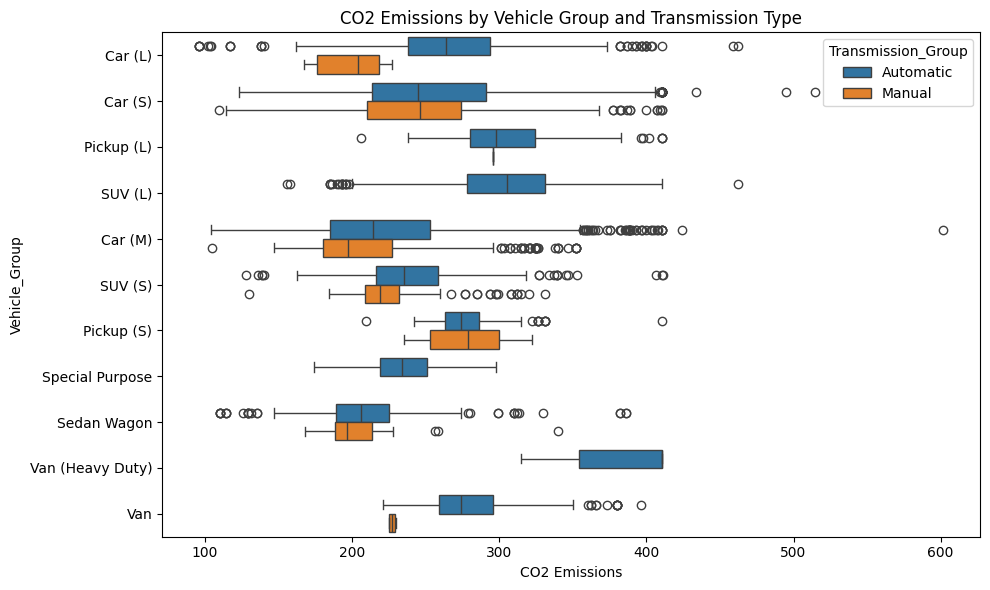

In [419]:
# Multivariate: CO2 Emissions by Vehicle Group and Transmission Group
plt.figure(figsize=(10, 6))
sns.boxplot(data=records, x='CO2 Emissions', y='Vehicle_Group', hue='Transmission_Group')
plt.title('CO2 Emissions by Vehicle Group and Transmission Type')
plt.tight_layout()
plt.show()

**Data Insight:**

Across most vehicle groups, automatic transmission vehicles produce higher median CO2 emissions than manual vehicles. The difference is most visible in Car (L), Car (S), and Car (M). Some categories such as SUV (L), Van (Heavy Duty), and Speical Purpose appear to have only automatic variants, with no or very few manual entries. Manual vehicles generally show a narrower and lower emission range.

**Business Interpretation:**

The consistent pattern of automatic vehicles emitting more CO2 across multiple vehicle categories reinforces the earlier finding that transmission type is a meaningful factor in emission levels. The absence of manual options in commercial categories (Vans, Speical Purpose and SUV (L) ) suggests these segments are exclusively served by automatic transmissions, limiting the scope for transmission-related emission comparisons in those groups.

**Recommendations:**

AESC should advise government agencies that within the same vehicle category, automatic vehicles tend to produce higher emissions than manual vehicles. This insight could support policies that incentivise the adoption of more fuel-efficient transmission technologies, particularly within the high-volume passenger car segments.

**Implications for ML Model Development:**

This multivariate analysis confirms that both Vehicle Group and Transmission Type contribute to explaining CO2 emission differences, supporting the inclusion of both as features in the regression model. The interaction between these two variables adds predictive value beyond what either variable provides individually.

**Grouping by Fuel Type**


In [ ]:
# Grouping by Fuel Type into new groups
# New sorted Fuel Type named Fuel_Group

# This way we have the origianl data and new sorted data for reference

def classify_fuel(f):
    if f == 'X':
        return 'Regular Gasoline'
    elif f == 'Z':
        return 'Premium Gasoline'
    elif f == 'D':
        return 'Diesel'
    elif f == 'E':
        return 'Ethanol (E85)'
    elif f == 'N':
        return 'Natural Gas'
    else:
        return f

records['Fuel_Group'] = records['Fuel Type'].apply(classify_fuel)
print(records['Fuel_Group'].value_counts())



**Data insight:**

The original Fuel Type column uses single-letter codes (X, Z, D, E, N) which are not intuitive for analysis. These were mapped to descriptive labels: Regular Gasoline, Premium Gasoline, Diesel, Ethanol (E85), and Natural Gas. Regular Gasoline (3,255) and Premium Gasoline (2,873) dominate the dataset, while Diesel (160), Ethanol (327), and Natural Gas (1) represent much smaller segments.

**Visualising Fuel_Group total counts**

In [ ]:
# Visualising Fuel_Group total counts
plt.figure()
sns.countplot(data=records, y='Fuel_Group', color='#A0D585')
plt.title('Distribution of Fuel_Group')
plt.xlabel('Total_Counts')
plt.tight_layout()
plt.show()

# Calculate percentage of each Fuel_Group (1 decimal place)
print((records['Fuel_Group'].value_counts(normalize=True) * 100).map('{:.1f}%'.format))

**Data Insight:**

Regular Gasoline and Premium Gasoline together account for over 92% of the dataset. Ethanol (E85) and Diesel represent small segments, while Natural Gas has only 1 record.

**Business Interpretation:**

The Australian vehicle market is heavily reliant on gasoline-powered vehicles. Alternative fuel types such as Diesel, Ethanol, and Natural Gas occupy a very small market share, reflecting limited consumer adoption or availability of these fuel options.

**Recommendations:**

AESC should advise government agencies that CO2 reduction policies targeting gasoline vehicles would have the broadest impact. Additionally, the extremely low representation of Natural Gas vehicles suggests an opportunity to promote cleaner fuel alternatives through incentives or infrastructure investment.

**Implications for ML Model Development:**
The severe imbalance in fuel type distribution means the model will have very limited training data for Diesel, Ethanol, and especially Natural Gas. The single Natural Gas record should be considered for removal, as it provides no meaningful learning value and could introduce noise. Predictions for non-gasoline fuel types may be less reliable.


###**Bivariate Fuel_Group vs CO2**

In [ ]:
# Visualising CO2 Emissions by Fuel_Group
plt.figure(figsize=(10, 6))
records.groupby('Fuel_Group')['CO2 Emissions'].mean().sort_values().plot(kind='barh')
plt.title('Average CO2 Emissions by Fuel_Group')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.tight_layout()
plt.show()

**Data Insight:**

Ethanol (E85) produces the highest average CO2 emissions at approximately 280 g/km, followed closely by Premium Gasoline at around 260 g/km. Diesel and Regular Gasoline produce similar emissions at approximately 240 g/km, while Natural Gas has the lowest at around 210 g/km. However, the Natural Gas value is based on only one record and should not be considered representative.

**Business Interpretation:**

The higher emissions from Ethanol (E85) and Premium Gasoline may be linked to their association with higher-performance vehicles that tend to have larger engines. Diesel and Regular Gasoline vehicles produce lower average emissions, suggesting more fuel-efficient engine configurations in these segments.

**Recommendations:**

AESC should advise government agencies that fuel type alone does not determine emission levels — vehicle specifications such as engine size and cylinders play a significant role. Policies should consider the combined effect of fuel type and vehicle characteristics rather than targeting fuel types in isolation.

**Implications for ML Model Development:**
Fuel type shows measurable variation in average CO2 emissions, supporting its inclusion as a feature in the regression model. However, the Natural Gas category with only one record should be handled carefully to avoid misleading the model during training.



In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=records, x='CO2 Emissions', y='Fuel_Group',color='#F2D479')
plt.title('CO2 Emissions by Fuel_Group')
plt.tight_layout()
plt.show()

**Data Insight:**

Premium Gasoline shows the wide range of IQR with outliers extending up to 600 g/km. Regular Gasoline has a broad spread but a lower median. Ethanol (E85) has a relatively narrow IQR centred around 280 g/km with a few low-end outliers. Diesel shows a compact distribution with one upper outlier. Natural Gas appears as a single data point with no spread.

**Business Interpretation:**

The wide emission range for Premium Gasoline confirms its association with a diverse mix of vehicles, from standard models to high-performance cars. Ethanol (E85) vehicles show more consistent emissions overall, though with some outliers at both ends. Diesel vehicles display the most consistent emission behaviour compared to other fuel types.

**Recommendations:**

AESC should highlight to government agencies that Premium Gasoline vehicles contain the most extreme high-emission outliers. Emission reduction efforts within this fuel category could focus on the highest emitters, as the wide variation suggests significant room for improvement among certain vehicle models.

**Implications for ML Model Development:**

The varying spread across fuel groups confirms that Fuel Group adds predictive value to the model. The single Natural Gas data point further supports the decision to remove or flag this record, as it provides no distributional information for model training.

### **Show treated Data frame**



In [ ]:
#summarise categorical columns as well
data_types =['object', 'float', 'int']
records.describe(include=data_types)

## **3. Machine Learning Model Development**

**Aim:** To demonstrate your understanding in AI modelling.

Use this section to show and discuss the process as relevant to the case study, key steps to run and complete the experiment, and details of models.

- Learning type (e.g., supervised or unsupervised, and why)
- Task type (e.g., regression or classification, and why)
- Algorithm selection and justification for its suitability to the task and business problem
- Target (label) and feature (predictor) selection, and why
- Data splitting ratio into training and testing sets, and why
- Feature transformations, such as encoding and scaling/normalisation

**Learning Type:**

Supervised learning was selected for this task, as the objective is to predict a specific value (CO2 Emissions) rather than discover hidden patterns in the data. The dataset contains a known target variable (CO2 Emissions) with labelled values, making it suitable for supervised learning. Unsupervised learning would be used for pattern discovery or clustering where no target label exists, which does not align with the business problem.

**Task Type:**

Regression was chosen because the business problem requires predicting a numerical estimation outcome — CO2 Emissions (g/km), which is a continuous value. Classification would only be appropriate if the goal were to assign vehicles into discrete categories, which is not the case here. CO2 Emissions was selected as the label (target variable) as it directly addresses AESC's objective of estimating vehicle emissions for government reporting.

**Algorithm Selection:**

Two approaches were implemented: Simple Linear Regression and Multiple Linear Regression. Simple Linear Regression was used to examine the relationship between a single predictor and CO2 Emissions, while Multiple Linear Regression was used to incorporate multiple features simultaneously for improved prediction accuracy. Linear regression was chosen for its interpretability and suitability for this business context, as AESC needs to clearly explain the relationship between vehicle specifications and emissions to government agencies.

**Target and Feature Selection:**

CO2 Emissions (g/km) was selected as the target variable, as it directly addresses the business problem of estimating vehicle emissions. Feature selection was informed by the exploratory analysis, including correlation heatmaps and boxplots. Cylinders and Engine Size were identified as strong numerical predictors due to their high correlations with CO2 Emissions (0.79 and 0.77 ). Categorical features such as Fuel Group, Vehicle Group, and Transmission Group were also included based on the meaningful emission differences observed during EDA. Dealer_State and color were excluded due to minimal variation in CO2 emissions across states.

**Data Splitting:**

The dataset was split into 70% training and 30% testing sets. The 70/30 ratio provides sufficient training data for the model to learn patterns while retaining enough test data for a reliable evaluation of model performance.

**Feature Transformations:**

Categorical variables (Fuel Group, Vehicle Group, Transmission Group) were encoded using one-hot encoding to convert them into numerical format suitable for regression. Numerical variables (Cylinders, Engine Size) were used without additional scaling, as linear regression does not require feature normalisation.

### **Simple Linear Regression**
we will use regression model becasue the prediction Y(CO2 Emissions) is a numerical data.

Potentiacally multi linear regression to improve the prediction outcome

In [ ]:
#feature selection
features=['Cylinders']
X=records[features]
X.head()



**Implications for ML Model Development:**

For the Simple Linear Regression model, Cylinders was selected as the single predictor variable based on the EDA findings, which showed it has the strongest correlation with CO2 Emissions (r = 0.79) among the numerical features.

In [ ]:
#specify the label
y=records['CO2 Emissions']
y.head()

**Implications for ML Model Development:**

CO2 Emissions (g/km) was assigned as the label (target variable), as it is the value the model aims to predict in order to address AESC's business objective of estimating vehicle emissions.

### **Split data**

In [ ]:



# Split dataset into training set 70% and test set 30% and lock random seed at 2025
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)


**Data and ML model insight:**

The dataset was split into 70% training (4,631 records) and 30% testing (1,985 records) using a random state of 2025 to ensure reproducibility. The 70/30 ratio provides sufficient training data for the model to learn patterns while retaining a meaningful test set for reliable performance evaluation.

### Training a linear regression model

In [ ]:
#create a linear_model object
reg = linear_model.LinearRegression()

**Train a model**


In [ ]:
# Train a Regression model (regressor) with the training dataset
reg=reg.fit(X_train, y_train)

### **Make predictions**

In [ ]:
#Make predictions for the test dataset
y_pred = reg.predict(X_test)

## **4. Model Evaluation and Post Analysis**

**Aim:** To demonstrate your understanding in model execution, evaluation, and interpretation, and to communicate findings and recommendations to the client.

**Model Performance and Metrics:**
- Model performance metrics and results
- Compare distributions of y_pred and y_test
- Compare error metrics (RMSE/MAE) against y_test statistics

**Residual Analysis:**
- Plot residuals (y_test – y_pred) and identify patterns, skewness, or heteroskedasticity
- Assess whether residuals have mean close to zero and constant spread

**Interpretation and Discussion:**
- Strengths and limitations of the model
- Non-random patterns or implications for model improvement

**Business Interpretation and Client Recommendations:**
- Interpret model performance and limitations in the context of the business problem and case study
- Discuss what the model results mean for the client's decision-making and operations
- Provide actionable recommendations based on the model's insights and limitations
- Address how the client can leverage or improve upon the model's predictions

### **Evaluate model performance**

In [ ]:


# R² , Adjusted R²
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]  # number of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R-squared: {r2:.2f}")
print(f"Adjusted R²: {adj_r2:.2f}")


# Calculate and print the mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"\nMean Absolute Error: {mae:.0f}")


# Calculate and print the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nRoot Mean Square Error: {rmse:.0f}")




**Implications for ML Model Development:**

A R-squared value of 0.62 means that the model explains 62% of the variance in the target variable based on the predictors used. In other words, the model captures about more than half of the patterns in the data, while the remaining 38% of the variation is due to factors not included in the model or random noise. This suggests that the model has limited explanatory power, and there may be room to improve it by adding more relevant features, transforming variables, or exploring alternative modelling approaches.

**Interpret MAE and RMSE in Context**

In [ ]:
#set the formatting for floating numbers
pd.set_option('display.float_format', lambda x: '%.0f' % x)
Cylinders = X_test['Cylinders']

#inspection
inspection=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
inspection=pd.DataFrame({'Cylinders':Cylinders, 'Actual':y_test, 'Predicted':y_pred})
inspection.head(20)

**ML Model Development insight:**

The model predictions were compared against actual CO2 Emissions values for the test set. The results show that the model predicts a fixed value for each cylinder count (e.g., approximately 210 g/km for 4 cylinders, 260 g/km for 6 cylinders, and 311 g/km for 8 cylinders). While the predictions capture the general trend of higher emissions with more cylinders, the model cannot account for variation within each cylinder group, as it relies on only one feature. This limitation supports the need for a Multiple Linear Regression model with additional predictors.



In [ ]:
# Examine the descriptive statistics of the Actual and Predicted prices of the test data
print(f"Mean Absolute Error: {mae:.0f}")
print(f"\nRoot Mean Square Error: {rmse:.0f}\n")
inspection[['Actual','Predicted']].describe()

**Model Performance Summary:**

The Simple Linear Regression model achieved a Mean Absolute Error (MAE) of 26 g/km and a Root Mean Square Error (RMSE) of 37 g/km. The mean predicted value (252 g/km) is close to the actual mean (250 g/km), indicating the model captures the overall trend well. However, the predicted standard deviation (47) is significantly lower than the actual (60), and the predicted range (185–512) is narrower than the actual range (96–602). This confirms that the model with only one feature (Cylinders) struggles to capture the full variation in CO2 emissions, particularly at the extreme ends.

The MAE of 26 g/km means the model's predictions are on average 26 g/km off from actual emissions. For AESC's emission estimation purposes, this level of error should be assessed against the acceptable tolerance for government reporting. The R-squared of 0.62 indicates the model explains 62% of the variance, which is a reasonable starting point but insufficient for reliable emission estimation. To address these limitations, a Multiple Linear Regression model incorporating additional features was developed to improve prediction accuracy.

In [ ]:
# Calculate mean and standard deviation of the actual prices in the test set
y_test_mean = y_test.mean()
y_test_std = y_test.std()

# Calculate percentage of MAE relative to the mean and standard deviation of y_test
mae_percent_of_mean = (mae / y_test_mean) * 100
mae_percent_of_std = (mae / y_test_std) * 100

# Calculate percentage of RMSE relative to the mean and standard deviation of y_test
rmse_percent_of_mean = (rmse / y_test_mean) * 100
rmse_percent_of_std = (rmse / y_test_std) * 100


print(f"Mean of y_test: {y_test_mean:.0f}")
print(f"\nStandard Deviation of y_test: {y_test_std:.0f}")
print(f"\nMAE is {mae_percent_of_mean:.2f}% of the mean of y_test")
print(f"\nMAE is {mae_percent_of_std:.2f}% of the standard deviation of y_test")
print(f"\nRMSE is {rmse_percent_of_mean:.2f}% of the mean of y_test")
print(f"\nRMSE is {rmse_percent_of_std:.2f}% of the standard deviation of y_test")

**Error Analysis:**

The MAE represents approximately 10.53% of the mean CO2 Emissions, indicating that on average, predictions deviate by about 10.53% from the actual values. The RMSE is 14.66% of the mean, which is slightly higher due to the influence of larger prediction errors. When compared to the standard deviation, the MAE accounts for 44.05% and the RMSE for 61.30%, suggesting that the model explains a reasonable portion of the variation but a significant amount of variability remains unexplained. This further supports the need for additional features in a Multiple Linear Regression model to improve prediction accuracy.

### **📝 Simple Regression Post-analysis**

In [ ]:
print('Intercept %.2f' % reg.intercept_)
print('coeffienct %.2f' % reg.coef_[0])
print('\nEstimate CO2 Emissions = ', '%.2f' % reg.intercept_, ' + ', '%.2f' % reg.coef_[0], ' x ', 'Cylinders')

###**Visualising the simple regression model**

In [ ]:
sns.scatterplot(data=inspection, x='Cylinders', y='Actual')
sns.regplot(data=inspection, x='Cylinders', y='Predicted', color='blue')




**Model Performance and Metrics:**

The scatter plot shows the actual CO2 Emissions (light blue dots) against the predicted values (dark blue regression line) based on Cylinders. The model captures the positive linear trend — as cylinder count increases, predicted emissions increase accordingly. However, at each cylinder value there is significant vertical scatter in actual emissions, confirming that Cylinders alone cannot explain the full variation in CO2 Emissions.

**Interpretation and Discussion:**

**Strengths:**
The model successfully captures the overall upward trend between Cylinders and CO2 Emissions. It is simple, interpretable, and easy to communicate to non-technical stakeholders such as government agencies.

**Limitations:**
The scatter reveals considerable variation within each cylinder group. For example, vehicles with 8 cylinders range from approximately 200 to 450 g/km, yet the model predicts a single value of around 311 g/km for all of them. At higher cylinder counts (12 and 16), the very few data points make predictions unreliable, with actual values ranging widely from 180 to 600 g/km.

**Business Interpretation and Client Recommendations:**

While this model provides AESC with a useful baseline for estimating CO2 emissions based on cylinder count, the prediction error is too large for precise emission reporting to government agencies. AESC should use this as a starting point and adopt the Multiple Linear Regression model with additional features to achieve more accurate and reliable emission estimates for policy decision-making.

### **Residuals plot to check for patterns, heteroscedasticity, and normality**

In [ ]:

# Calculate residuals
residuals = y_test - y_pred

# Create a residual plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("CO2 Emissions Residual Plot")
plt.show()
print('\n')


In [ ]:
# Calculate percentage of residuals within -100 to 100
within_range = ((residuals >= -100) & (residuals <= 100)).sum() / len(residuals) * 100
print(f"Percentage of residuals within -100 to 100: {within_range:.1f}%")

**Residual Analysis:**

The residuals are scattered around the zero line (red dashed line), indicating no strong systematic bias in the model's predictions. However, the residuals show a clear pattern of vertical clustering at discrete predicted values (corresponding to each cylinder count), which is expected given the single-feature model. The residual spread ranges from approximately -250 to +200 g/km, and the spread appears relatively consistent across predicted values, suggesting no severe heteroscedasticity.

**Interpretation and Discussion:**

**Strengths:**
The residual mean appears close to zero, indicating the model does not systematically over- or under-predict CO2 emissions overall. The residuals are roughly symmetrically distributed above and below zero at each predicted value.The majority of prediction errors fall within the -100 to +100 g/km range.

**Limitations:**
The vertical clustering pattern confirms that the model can only predict a limited set of discrete values based on cylinder count. The wide residual range (approximately -250 to +200 g/km) shows that individual predictions can be substantially off, even though the average error is manageable. This non-random clustering pattern indicates that additional predictors are needed to reduce the within-group variation.



**Business Interpretation and Client Recommendations:**

The residual analysis confirms that while the Simple Linear Regression model provides a reasonable baseline, the prediction errors for individual vehicles can be significant. For AESC's reporting to government agencies, a prediction error of up to 200 g/km for some vehicles would be too large for reliable emission estimation. The Multiple Linear Regression model with additional features should reduce these residual errors and provide more dependable estimates for policy decision-making.



In [ ]:
# Plotting residuals against a predictor variable (e.g., area) to check for patterns
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test['Cylinders'], y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Cylinders")
plt.ylabel("Residuals")
plt.title("Residuals vs. Cylinders")
plt.show()

**Model Performance and Metrics:**

The Residuals vs. Cylinders plot shows that residuals are scattered around zero across all cylinder values, with no unusual pattern observed. The spread of residuals is relatively consistent for cylinders 3 to 8, but becomes more extreme at 12 and 16 cylinders where larger residuals appear due to the very limited data points in those categories.

**Interpretation and Discussion:**

**Strengths:**
No clear non-random pattern is observed in the residuals, and the assumptions of normality and homoscedasticity appear reasonable for the mainstream cylinder range (3 to 8). The model performs best within this range where the majority of training data is concentrated.

**Limitations:**

At 12 and 16 cylinders, outliers with large residuals are evident, indicating the model struggles with these rare high-cylinder vehicles. Since Cylinders is a discrete variable, data points align vertically at specific values, limiting the model's ability to capture within-group variation.

**Business Interpretation and Client Recommendations:**

The residual analysis confirms that the Simple Linear Regression model provides acceptable estimates for mainstream vehicles (3 to 8 cylinders) but is unreliable for rare high-cylinder vehicles. For AESC's reporting purposes, emission estimates for vehicles with 12 or more cylinders should be treated with caution. Additional variables with strong correlations to CO2 Emissions should be incorporated through a Multiple Linear Regression model to improve overall prediction accuracy.





### **histogram and Q-Q plot**

In [ ]:
# Plot a histogram of residuals to check for normality
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# Plot a Q-Q plot to further check for normality

plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

**Model Performance and Metrics:**

The histogram of residuals shows a roughly bell-shaped distribution centred near zero, suggesting the residuals approximate a normal distribution. The Q-Q plot confirms this — most data points follow the red diagonal line closely in the central range, but deviate at both tails, indicating heavier tails than a perfect normal distribution.

**Interpretation and Discussion:**

**Strengths:**
The residuals are centred around zero with an approximately normal distribution, which satisfies a key assumption of linear regression.

**Limitations:**
The Q-Q plot reveals deviations at both extremes — the lower tail drops below the line and the upper tail curves above it. This means the model produces larger-than-expected errors for both very low and very high emission vehicles. These heavy tails are consistent with the outliers identified during the EDA.


**Business Interpretation and Client Recommendations:**

The residual distribution confirms that the Simple Linear Regression model is reasonably reliable for the majority of mainstream vehicles. However, AESC should be aware that emission estimates for vehicles at the extreme ends may be less trustworthy. Incorporating additional features through Multiple Linear Regression should help reduce these tail errors and produce more normally distributed residuals.

## **Multi-linear regression**

In [ ]:
records.info()


### **Multi Regression relative variables**

###**Dummies Coding Vehicle_Group for Multi-Regression**



In [ ]:
# using dummy coding for multi_regression model
vehicle_dummies = pd.get_dummies(records['Vehicle_Group'], prefix='Vehicle', drop_first=True)
records = pd.concat([records, vehicle_dummies], axis=1)

# print to see if dummies variables are successed
print('\nDummy Coding for Vehicle',records.filter(like='Vehicle_').columns.tolist())

**ML Model Development:**

Dummy coding (one-hot encoding) was applied to the categorical variable Vehicle_Group to convert it into a numerical format suitable for the regression model. The drop_first=True parameter was used to avoid multicollinearity by dropping one category as the reference group. This allows the model to compare emissions across vehicle groups relative to the baseline category.

### **Dummies Coding Fuel_Group for Multi-Regression**

In [ ]:
# using dummy coding for multi_regression model
fuel_dummies = pd.get_dummies(records['Fuel_Group'], prefix='Fuel', drop_first=True)
records = pd.concat([records, fuel_dummies], axis=1)

# print to see if dummies variables are successed
print('\nDummy Coding for Fuel',records.filter(like='Fuel_').columns.tolist())

**ML Model Development:**

Dummy coding (one-hot encoding) was applied to the categorical variable Fuel_Group to convert it into a numerical format suitable for the regression model. The drop_first=True parameter was used to avoid multicollinearity by dropping one category as the reference group. This allows the model to compare emissions across vehicle groups relative to the baseline category.

### **Multi-Regression model: Cylinders, Vehicle_Group**

In [ ]:
#select relevant variables and train and evaluate a model.
# getting all col.startswith Vehicle_ but not Vehicle_Group
# R2  = 0.71

mul_vehicle_cols = [col for col in records.columns if col.startswith('Vehicle_') and col != 'Vehicle_Group']


X = records[['Cylinders'] + mul_vehicle_cols ]
print(f"X shape: {X.shape}")
print(X.columns.tolist())

**Multi-Regression model: Cylinders, Vehicle_Group**

In [ ]:
#select relevant variables and train and evaluate a model.
# getting all col.startswith Vehicle_ but not Vehicle_Group
# getting all col.startswith Fuel_ but not Fuel_Group
# R2  = 0.73

mul_vehicle_cols = [col for col in records.columns if col.startswith('Vehicle_') and col != 'Vehicle_Group']


X = records[['Cylinders'] + mul_vehicle_cols]

In [ ]:
#specify the label
y=records['CO2 Emissions']
y.head()

###**Splitting data**

In [ ]:
##write your code to split dataset into training set 70% and test set 30%,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)




In [ ]:
##write your code to create a linear_model object
mul_reg = linear_model.LinearRegression()

In [ ]:
# ##write your code to train a Regression model (regressor) with the training dataset, see SECTION 1.10
mul_reg = mul_reg.fit(X_train, y_train)

### **Evaluate Mul_Reg model performance**

In [ ]:
y_pred = mul_reg.predict(X_test)
# Update inspection for Multiple Regression
inspection = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# R² , Adjusted R²
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]  # number of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R-squared: {r2:.2f}")
print(f"Adjusted R²: {adj_r2:.2f}")

# Calculate and print the mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.0f}")

# Calculate and print the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse:.0f}")
inspection[['Actual','Predicted']].describe()

**Multi-Regression model: Cylinders, Engine Size**

In [ ]:
# select relevant features and train and evaluate a model. For example
features=['Cylinders', 'Engine Size']
X=records[features]

In [ ]:
y=records['CO2 Emissions']
y.head()

###**Splitting data**

In [ ]:
##write your code to split dataset into training set 70% and test set 30%,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)




In [ ]:
##write your code to create a linear_model object
mul_reg = linear_model.LinearRegression()

In [ ]:
# ##write your code to train a Regression model (regressor) with the training dataset, see SECTION 1.10
mul_reg = mul_reg.fit(X_train, y_train)

### **Evaluate Mul_Reg model performance**

In [ ]:
y_pred = mul_reg.predict(X_test)
# Update inspection for Multiple Regression
inspection = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# R² , Adjusted R²
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]  # number of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R-squared: {r2:.2f}")
print(f"Adjusted R²: {adj_r2:.2f}")

# Calculate and print the mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.0f}")

# Calculate and print the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse:.0f}")
inspection[['Actual','Predicted']].describe()

### **Multi-Regression model: Cylinders, Vehicle_Group, Fuel_Group**

In [ ]:
#select relevant variables and train and evaluate a model.
# getting all col.startswith Vehicle_ but not Vehicle_Group
# getting all col.startswith Fuel_ but not Fuel_Group
# R2  = 0.73

mul_vehicle_cols = [col for col in records.columns if col.startswith('Vehicle_') and col != 'Vehicle_Group']
mul_fuel_cols = [col for col in records.columns if col.startswith('Fuel_') and col != 'Fuel_Group']

X = records[['Cylinders'] + mul_vehicle_cols + mul_fuel_cols]
print(f"X shape: {X.shape}")
print(X.columns.tolist())


In [ ]:
#specify the label
y=records['CO2 Emissions']
y.head()

###**Splitting data**

In [ ]:
##write your code to split dataset into training set 70% and test set 30%,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)




In [ ]:
##write your code to create a linear_model object
mul_reg = linear_model.LinearRegression()

In [ ]:
# ##write your code to train a Regression model (regressor) with the training dataset, see SECTION 1.10
mul_reg = mul_reg.fit(X_train, y_train)

### **Evaluate Mul_Reg model performance**

In [ ]:
y_pred = mul_reg.predict(X_test)
# Update inspection for Multiple Regression
inspection = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# R² , Adjusted R²
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]  # number of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R-squared: {r2:.2f}")
print(f"Adjusted R²: {adj_r2:.2f}")

# Calculate and print the mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.0f}")

# Calculate and print the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse:.0f}")
inspection[['Actual','Predicted']].describe()

**ML Model Development:**

For the Multiple Linear Regression model, Cylinders was retained as the numerical predictor due to its highest correlation with CO2 Emissions (r = 0.79). Engine Size was excluded despite its strong correlation with CO2 Emissions (r = 0.77), as it has a high collinearity with Cylinders (r = 0.82), which could negatively affect model stability. Vehicle Group and Fuel Group were included as additional categorical features based on the EDA findings, which demonstrated meaningful differences in CO2 emissions across both vehicle categories and fuel types.

In [ ]:
# Calculate mean and standard deviation of the actual prices in the test set
y_test_mean = y_test.mean()
y_test_std = y_test.std()

# Calculate percentage of MAE relative to the mean and standard deviation of y_test
mae_percent_of_mean = (mae / y_test_mean) * 100
mae_percent_of_std = (mae / y_test_std) * 100

# Calculate percentage of RMSE relative to the mean and standard deviation of y_test
rmse_percent_of_mean = (rmse / y_test_mean) * 100
rmse_percent_of_std = (rmse / y_test_std) * 100

print(f"Mean of y_test: {y_test_mean:.0f}")
print(f"Standard Deviation of y_test: {y_test_std:.0f}")
print(f"MAE is {mae_percent_of_mean:.2f}% of the mean of y_test")
print(f"MAE is {mae_percent_of_std:.2f}% of the standard deviation of y_test")
print(f"RMSE is {rmse_percent_of_mean:.2f}% of the mean of y_test")
print(f"RMSE is {rmse_percent_of_std:.2f}% of the standard deviation of y_test")

**Extract and Visualise Feature Importance**

To identify which predictors contribute most to the model and guide decisions on feature selection or interpretation, we extract and visualise feature importance using the coefficients from a linear regression model.

In [ ]:
# Get feature importance (coefficients for Linear Regression)
importance = mul_reg.coef_

# Summarize feature importance
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importance})

# Sort by importance (absolute value)
feature_importance['importance_abs'] = np.abs(feature_importance['importance'])
feature_importance = feature_importance.sort_values('importance_abs', ascending=False).drop(columns='importance_abs')

print("\nFeature Importance (Linear Regression Coefficients):")
print(feature_importance)


# Print the full regression equation
equation = f"\nEstimate CO2 Emissions = {mul_reg.intercept_:.2f}"
for name, coef in zip(X.columns, mul_reg.coef_):
    if coef >= 0:
        equation += f" + {coef:.2f} × {name}"
    else:
        equation += f" - {abs(coef):.2f} × {name}"
print(equation)


**Inspect the predictions and the original labels**

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual CO2 vs Predicted CO2")
plt.show()

**Model Performance and Metrics:**

The Actual vs Predicted scatter plot shows that the majority of data points cluster around the red dashed line (perfect prediction line), indicating the Multiple Linear Regression model captures the overall relationship well. The model performs best in the 100–380 g/km range where points are tightly grouped along the line.

**Interpretation and Discussion:**

**Strengths:**
Compared to the Simple Linear Regression model, the predictions are no longer limited to a few fixed values — the model now produces a continuous range of predictions thanks to the inclusion of Vehicle Group and Fuel Group features. The tighter clustering around the diagonal line confirms the improvement from R² = 0.62 to R² = 0.73.

**Limitations:**
At the high emission end (above 400 g/km), several points deviate significantly from the diagonal line. For example, a vehicle with actual emissions of approximately 600 g/km was predicted at only around 380 g/km. This indicates the model still underestimates emissions for extreme high-emission vehicles, consistent with the limited training data in this range identified during EDA.

**Business Interpretation and Client Recommendations:**

The Multiple Linear Regression model provides AESC with a more reliable emission estimation tool compared to the single-feature model. For the majority of mainstream vehicles (100–380 g/km), predictions are sufficiently close to actual values for practical use in government reporting. However, AESC should advise that emission estimates for high-emission vehicles (above 400 g/km) carry greater uncertainty and may require additional verification before being used for policy decisions.

### **✅ Final Multi-Regression model: Cylinders, Vehicle_Group, Fuel_Group, Engine Size**

In [ ]:
# Multi-Regression, Cylinders, Vehicle_Group, Fuel_Group, R2 0.75
vehicle_cols = [col for col in records.columns if col.startswith('Vehicle_') and col != 'Vehicle_Group']
fuel_cols = [col for col in records.columns if col.startswith('Fuel_') and col != 'Fuel_Group']

X = records[['Cylinders', 'Engine Size'] + vehicle_cols + fuel_cols]
y = records['CO2 Emissions']


print(f"X shape: {X.shape}")
print(X.columns.tolist())

In [ ]:
y=records['CO2 Emissions']
y.head()

###**Splitting data**

In [ ]:
##write your code to split dataset into training set 70% and test set 30%,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2025)

#inspect the split datasets
print(X_train.head())
print(y_train.head())

print('Training dataset size:',X_train.shape)
print('Test dataset size:',X_test.shape)




In [ ]:
##write your code to create a linear_model object
mul_reg = linear_model.LinearRegression()

In [ ]:
# ##write your code to train a Regression model (regressor) with the training dataset, see SECTION 1.10
mul_reg = mul_reg.fit(X_train, y_train)

### **Evaluate Mul_Reg model performance**

In [ ]:
y_pred = mul_reg.predict(X_test)
# Update inspection for Multiple Regression
inspection = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# R² , Adjusted R²
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]  # number of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R-squared: {r2:.2f}")
print(f"Adjusted R²: {adj_r2:.2f}")

# Calculate and print the mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.0f}")

# Calculate and print the root mean square error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {rmse:.0f}")
inspection[['Actual','Predicted']].describe()

In [ ]:
# Calculate mean and standard deviation of the actual prices in the test set
y_test_mean = y_test.mean()
y_test_std = y_test.std()

# Calculate percentage of MAE relative to the mean and standard deviation of y_test
mae_percent_of_mean = (mae / y_test_mean) * 100
mae_percent_of_std = (mae / y_test_std) * 100

# Calculate percentage of RMSE relative to the mean and standard deviation of y_test
rmse_percent_of_mean = (rmse / y_test_mean) * 100
rmse_percent_of_std = (rmse / y_test_std) * 100

print(f"Mean of y_test: {y_test_mean:.0f}")
print(f"Standard Deviation of y_test: {y_test_std:.0f}")
print(f"MAE is {mae_percent_of_mean:.2f}% of the mean of y_test")
print(f"MAE is {mae_percent_of_std:.2f}% of the standard deviation of y_test")
print(f"RMSE is {rmse_percent_of_mean:.2f}% of the mean of y_test")
print(f"RMSE is {rmse_percent_of_std:.2f}% of the standard deviation of y_test")

**Inspect the predictions and the original labels**

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual CO2 vs Predicted CO2")
plt.show()

**Model Performance and Metrics:**

The Actual vs Predicted scatter plot shows that the majority of data points cluster around the red dashed line (perfect prediction line), indicating the Multiple Linear Regression model captures the overall relationship well. The model performs best in the 100–400 g/km range where points are tightly grouped along the line.

**Interpretation and Discussion:**

Strengths: Compared to the Simple Linear Regression model, the predictions are no longer limited to a few fixed values — the model now produces a continuous range of predictions thanks to the inclusion of Engine Size, Vehicle Group and Fuel Group features. The tighter clustering around the diagonal line confirms the improvement from R² = 0.62 to Adjusted R² = 0.75. The inclusion of Engine Size alongside Cylinders, despite their high collinearity (r = 0.82), was justified as the combined model improved Adjusted R² from 0.728 to 0.753 and reduced MAE from 21.5 to 20.6 g/km.

**Limitations:**

At the high emission end (above 400 g/km), several points deviate significantly from the diagonal line. For example, a vehicle with actual emissions of approximately 600 g/km was predicted at only around 370 g/km. This indicates the model still underestimates emissions for extreme high-emission vehicles, consistent with the limited training data in this range identified during EDA.

**Business Interpretation and Client Recommendations:**

The Multiple Linear Regression model provides AESC with a more reliable emission estimation tool compared to the single-feature model. For the majority of mainstream vehicles (100–400 g/km), predictions are sufficiently close to actual values for practical use in government reporting. However, AESC should advise that emission estimates for high-emission vehicles (above 400 g/km) carry greater uncertainty and may require additional verification before being used for policy decisions.

**Getting the Intercept and Coefficients**

In [ ]:
# Print all coefficients with feature names
for name, coef in zip(X.columns, mul_reg.coef_):
    print(f"{name}: {coef:.2f}")
print(f"Intercept: {mul_reg.intercept_:.2f}")

**Extract and Visualise Feature Importance**

To identify which predictors contribute most to the model and guide decisions on feature selection or interpretation, we extract and visualise feature importance using the coefficients from a linear regression model.

In [ ]:
# Get feature importance (coefficients for Linear Regression)
importance = mul_reg.coef_

# Summarize feature importance
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importance})

# Sort by importance (absolute value)
feature_importance['importance_abs'] = np.abs(feature_importance['importance'])
feature_importance = feature_importance.sort_values('importance_abs', ascending=False).drop(columns='importance_abs')

print("\nFeature Importance (Linear Regression Coefficients):")
print(feature_importance)


# Print the full regression equation
equation = f"\nEstimate CO2 Emissions = {mul_reg.intercept_:.2f}"
for name, coef in zip(X.columns, mul_reg.coef_):
    if coef >= 0:
        equation += f" + {coef:.2f} × {name}"
    else:
        equation += f" - {abs(coef):.2f} × {name}"
print(equation)


##📝 💯 ✅ 作業！！！  

## 可能刪掉gas?

## Vehicle Group 可能可以加進model?

**Data Insight:**

**Business Interpretation:**

**Recommendations:**

**Implications for ML Model Development:**


## **📝 💯 ✅POST**

**Model Performance and Metrics:**

**Interpretation and Discussion:**

**Strengths:**

**Limitations:**

**Business Interpretation and Client Recommendations:**


⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️